# Q-Learning Agent for a 2D Platform-Collector Game (Basic & Advanced Scenes)

**UCCD2063 Artificial Intelligence Techniques — Practical Assignment — Scene 4**

This notebook implements a **tabular Q-Learning** agent that learns to play the 2D platform-collector game built in Godot. The agent must collect two apples while avoiding its snail enemies, communicating with the Godot scene over a **WebSocket on `127.0.0.1:9080`**.

All code below is inlined from the `reinforcement_learning/` folders of `as-4_basic` and `as-4_advanced` — `config.py`, `environment.py`, `q_learning.py`, `trainer.py`, `evaluate.py`, `tester.py` — so the notebook is self-contained.

**Requirements to run this notebook:**
- The corresponding Godot scene must be open and running in the Godot editor (Basic Scene: `main.tscn`; Advanced Scene: `level_root_advanced.tscn`), listening on `127.0.0.1:9080`, before running the training or evaluation cells below.
- The result cells (loading `qtable.pkl` and the saved training curves) do **not** require Godot — they load the outputs of the completed run and are already executed, with their output preserved below.
- The training and live-evaluation cells **do** require Godot and are provided as runnable code; run them yourself with the appropriate scene open to reproduce the results.

> Tip: run the notebook from the `Downloads` folder so the `as-4_basic` / `as-4_advanced` paths resolve. A fallback search of `Downloads` under the user home is included in the setup cell.

## 1. Setup and Imports

In [1]:
%matplotlib inline
import os
import sys
import json
import random
import pickle
import time
from pathlib import Path
from collections import Counter

import numpy as np
import matplotlib
import matplotlib.pyplot as plt

# The notebook lives in Downloads; the scene folders sit next to it.
def _find_rl_dir(folder_name):
    for base in (Path.cwd(), Path.home() / "Downloads", Path.home()):
        candidate = base / folder_name / "reinforcement_learning"
        if candidate.is_dir():
            return candidate
    return Path.cwd() / folder_name / "reinforcement_learning"

BASIC_RL = _find_rl_dir("as-4_basic")
ADVANCED_RL = _find_rl_dir("as-4_advanced")

print("Python:", sys.version.split()[0])
print("matplotlib:", matplotlib.__version__)
print("Basic RL dir    :", BASIC_RL)
print("Advanced RL dir :", ADVANCED_RL)
print("Basic qtable    :", (BASIC_RL / "qtable.pkl").exists())
print("Advanced qtable :", (ADVANCED_RL / "qtable.pkl").exists())


Python: 3.13.5
matplotlib: 3.11.0
Basic RL dir    : C:\Users\weiye\Downloads\as-4_basic\reinforcement_learning
Advanced RL dir : C:\Users\weiye\Downloads\as-4_advanced\reinforcement_learning
Basic qtable    : True
Advanced qtable : True


## 2. Configuration & Hyperparameters

`config.py` defines the connection settings, the legacy top-level Q-learning defaults that mirror the default experiment, and five named experiment configurations. All training in this notebook uses the **default** experiment (1,000 episodes, lr = 0.1, γ = 0.98, ε from 1.0 decaying by 0.997 down to 0.02).

In [2]:
# ==========================
# RL Server Connection
# ==========================
RL_HOST = "127.0.0.1"
RL_PORT = 9080
CONNECT_TIMEOUT = 10.0   # seconds
STEP_TIMEOUT = 5.0       # seconds

# ==========================
# Q-Learning Hyperparameters
# ==========================
# Legacy top-level defaults retained for compatibility; trainer.py uses the
# selected EXPERIMENTS entry below. The default experiment is 1000 episodes.
# With lockstep actions of 0.1s, MAX_STEPS=1800 permits 180s per episode.
MAX_STEPS = 1800
LEARNING_RATE = 0.1
DISCOUNT_FACTOR = 0.98

EPSILON = 1.0
EPSILON_DECAY = 0.997
MIN_EPSILON = 0.02

# ==========================
# Experiment Configurations
# ==========================
EXPERIMENTS = {
    "default": {
        "episodes": 1000,
        "lr": 0.1,
        "gamma": 0.98,
        "epsilon": 1.0,
        "epsilon_decay": 0.997,
        "min_epsilon": 0.02,
    },
    # Focused continuation: high exploration floor so the apple1 climb gets
    # enough samples for the greedy policy to follow it reliably.
    "resume": {
        "episodes": 600,
        "lr": 0.1,
        "gamma": 0.98,
        "epsilon": 0.3,
        "epsilon_decay": 0.998,
        "min_epsilon": 0.1,
    },
    "slower_decay": {
        "episodes": 1500,
        "lr": 0.1,
        "gamma": 0.95,
        "epsilon": 1.0,
        "epsilon_decay": 0.997,
        "min_epsilon": 0.05,
    },
    "higher_lr": {
        "episodes": 1000,
        "lr": 0.2,
        "gamma": 0.95,
        "epsilon": 1.0,
        "epsilon_decay": 0.995,
        "min_epsilon": 0.05,
    },
    "lower_gamma": {
        "episodes": 1000,
        "lr": 0.1,
        "gamma": 0.90,
        "epsilon": 1.0,
        "epsilon_decay": 0.995,
        "min_epsilon": 0.05,
    },
}

# ==========================
# State Discretization Bins
# ==========================
# Compact 9-feature state. Enemy timing preserves relative position and motion
# direction so the agent can wait or jump around a moving snail.
# This space is 63,360 states and remains practical for tabular learning.
# Features (tuple order in environment._discretize):
#   px, py, on_ground, apple_dir_x, apple_dir_y, apple_dist,
#   enemy_timing, apples_collected, near_gap
# Dropped: alive (terminal-only), vx_sign, and raw enemy position/direction.
STATE_BINS = {
    "px": 8,               # player x (0.0-1.0), 160px per bin
    "py": 5,               # player y (0.0-1.0), 144px per bin (separates the 3 platform levels)
    "on_ground": 2,        # 0 or 1
    "apple_dir_x": 3,      # -1, 0, 1
    "apple_dir_y": 3,      # -1, 0, 1  (vertical direction to nearest apple)
    "apple_dist": 2,       # near (<375px), far
    "enemy_timing": 11,    # far + 5 relative-x zones × 2 motion directions
    "apples_collected": 2, # 0 or 1 (2 = episode already over)
    "near_gap": 2,         # 0 or 1 — physics raycast, not hardcoded
}


## 3. Environment Interface

`GodotEnv` (from `environment.py`) is a **WebSocket client** for the Godot RL server. Each call to `step()` sends the chosen action and blocks until Godot returns the next state, reward, and termination flag, plus an info dict (`apples_collected`, `enemy_hit`, `fell_off`, …). `reset()` starts a fresh episode. The raw continuous state is discretised by `_discretize()` into a 9-feature tuple for tabular Q-learning.

In [3]:
"""
Godot RL Environment — WebSocket client for the 2D Platform Collector Game.

Communicates with the Godot game via WebSocket.
Discretizes continuous state for Q-learning.
"""
import json
import websocket
# (import line from environment.py: config names are defined in the config cell above)


class GodotEnv:
    """Environment wrapper that communicates with the running Godot game."""

    def __init__(self, host=RL_HOST, port=RL_PORT, debug=False):
        self.host = host
        self.port = port
        self.ws = None
        self.connected = False
        self.debug = debug
        self.episode_steps = 0

    # ------------------------------------------------------------------
    # Connection
    # ------------------------------------------------------------------
    def connect(self) -> bool:
        """Connect to the Godot RL server. Returns True on success."""
        url = f"ws://{self.host}:{self.port}"
        try:
            self.ws = websocket.create_connection(url, timeout=CONNECT_TIMEOUT)
            self.connected = True
            print(f"Connected to Godot at {url}")
            return True
        except Exception as e:
            print(f"Failed to connect to Godot: {e}")
            print("Make sure the Godot game is running first.")
            self.connected = False
            return False

    def disconnect(self):
        """Close the WebSocket connection."""
        if self.ws:
            try:
                self._send_msg({"type": "close"})
                self.ws.close()
            except Exception:
                pass
            self.ws = None
            self.connected = False

    # ------------------------------------------------------------------
    # RL Interface
    # ------------------------------------------------------------------
    def reset(self):
        """Reset the scene and return initial discrete state."""
        self.episode_steps = 0
        if self.debug:
            print("[PY] reset() sending reset msg")
        self._send_msg({"type": "reset"})
        response = self._recv_msg()
        if response is None:
            raise ConnectionError("No response from Godot on reset")
        if self.debug:
            print("[PY] reset() got response, reward=", response.get("reward"), "done=", response.get("done"))
        raw = response.get("state", {})
        disc = self._discretize(raw)
        if self.debug:
            print("[PY] reset() disc_state=", disc)
        return disc

    def step(self, action: int):
        """Apply action, return (discrete_state, reward, done, info)."""
        if self.debug:
            print("[PY] step() action=", action)
        self._send_msg({"type": "action", "action": action})
        response = self._recv_msg()
        if response is None:
            raise ConnectionError("No response from Godot on step")
        if self.debug:
            print("[PY] step() got response, reward=", response.get("reward"), "done=", response.get("done"))
        raw_state = response.get("state", {})
        reward = response.get("reward", 0.0)
        done = response.get("done", False)
        info = response.get("info", {})
        self.episode_steps += 1
        if self.episode_steps >= MAX_STEPS and not done:
            done = True
            info["max_steps_reached"] = True
        discrete_state = self._discretize(raw_state)
        if self.debug:
            print("[PY] step() disc_state=", discrete_state)
        return discrete_state, reward, done, info

    # ------------------------------------------------------------------
    # State discretization
    # ------------------------------------------------------------------
    def _discretize(self, raw: dict) -> tuple:
        """Convert raw Godot state into a discrete tuple for Q-learning.

        State features (in tuple order):
          px, py, on_ground, apple_dir_x, apple_dir_y,
          apple_dist, enemy_timing, apples_collected, near_gap

        Total state space: 8*5*2*3*3*2*11*2*2 = 63,360
        """
        if not raw:
            return tuple(0 for _ in STATE_BINS)

        bins = STATE_BINS

        # px: 0.0-1.0 -> 0..(bins-1)  (8 bins, 160px each)
        px = min(int(raw.get("px", 0.0) * bins["px"]), bins["px"] - 1)

        # py: 0.0-1.0 -> 0..(bins-1)  (5 bins, 144px each - separates the 3 platform levels)
        py = min(int(raw.get("py", 0.0) * bins["py"]), bins["py"] - 1)

        # on_ground: 0 or 1
        on_ground = int(raw.get("on_ground", 0))

        # apple_dir_x: -1,0,1 -> 0,1,2
        adx = raw.get("apple_dir_x", 0) + 1

        # apple_dir_y: -1,0,1 -> 0,1,2  (vertical direction to nearest apple)
        ady = raw.get("apple_dir_y", 0) + 1

        # apple_dist: 0.0-1.0 -> 0 near (<375px), 1 far
        apple_dist = 0 if raw.get("apple_dist", 0.0) < 0.25 else 1

        # enemy_timing: 0 far; 1..10 encode five relative-x zones and
        # the snail's left/right movement direction.
        enemy_timing = min(max(int(raw.get("enemy_timing", 0)), 0), 10)

        # apples_collected: 0 or 1 (2 = episode already over, no decision needed)
        apples_collected = min(int(raw.get("apples_collected", 0)), 1)

        # near_gap: 0 or 1 (physics-based gap detection ahead of player)
        near_gap = int(raw.get("near_gap", 0))

        return (px, py, on_ground, adx, ady, apple_dist,
                enemy_timing, apples_collected, near_gap)

    # ------------------------------------------------------------------
    # Messaging
    # ------------------------------------------------------------------
    def _send_msg(self, data: dict):
        """Send JSON message to Godot."""
        if not self.ws:
            raise ConnectionError("Not connected to Godot")
        msg = json.dumps(data)
        if self.debug:
            print(f"[PY] send: {msg}")
        self.ws.send(msg)

    def _recv_msg(self) -> dict:
        """Receive JSON message from Godot."""
        if not self.ws:
            return None
        try:
            self.ws.settimeout(STEP_TIMEOUT)
            raw = self.ws.recv()
            if raw is None:
                print("[PY] recv: connection closed (None)")
                self.connected = False
                return None
            if isinstance(raw, bytes):
                raw = raw.decode("utf-8")
            if self.debug:
                print(f"[PY] recv: {raw[:200]}")
            return json.loads(raw)
        except websocket.WebSocketTimeoutException:
            print("Timeout waiting for Godot response")
            return None
        except (ConnectionError, ConnectionResetError, BrokenPipeError) as e:
            print(f"Connection lost: {e}")
            self.connected = False
            return None
        except Exception as e:
            print(f"Error receiving from Godot: {type(e).__name__}: {e}")
            self.connected = False
            return None


## 4. State Discretisation

Nine features are extracted from the continuous Godot state (player x/y bins, grounded flag, direction and distance to the nearest apple, a 11-level enemy-timing encoding, apples-collected flag and a physics-based gap detector). The state space is 

`8 × 5 × 2 × 3 × 3 × 2 × 11 × 2 × 2 = 63,360` discrete states — compact enough for tabular Q-learning.

In [4]:
# Total size of the discretised state space (STATE_BINS from config.py)
size = 1
for name, bins in STATE_BINS.items():
    size *= bins
print("State space size:", size)
print("Features (tuple order):", list(STATE_BINS.keys()))


State space size: 63360
Features (tuple order): ['px', 'py', 'on_ground', 'apple_dir_x', 'apple_dir_y', 'apple_dist', 'enemy_timing', 'apples_collected', 'near_gap']


## 5. Q-Learning Agent

`QLearning` (from `q_learning.py`) stores a value for every visited (state, action) pair in a sparse dictionary (63,360 × 6 possible pairs), selects actions with **ε-greedy** exploration over the 6 actions (idle, right, left, jump, right+jump, left+jump), and updates with the standard Bellman rule. Greedy selection uses fixed tie-breaking so evaluation runs are reproducible.

In [5]:
import random
import pickle

NUM_ACTIONS = 6  # 0=idle 1=right 2=left 3=jump 4=right+jump 5=left+jump


class QLearning:

    def __init__(self, learning_rate, discount_factor):
        self.lr = learning_rate
        self.gamma = discount_factor
        self.q_table = {}

    def get_q_value(self, state, action):
        key = (state, action)
        if key not in self.q_table:
            self.q_table[key] = 0.0
        return self.q_table[key]

    def choose_action(self, state, epsilon):
        # Epsilon-greedy over all 6 actions
        if random.random() < epsilon:
            return random.randint(0, NUM_ACTIONS - 1)

        q_values = [self.get_q_value(state, a) for a in range(NUM_ACTIONS)]
        max_q = max(q_values)
        # Fixed tie-breaking keeps greedy evaluation reproducible. Exploration
        # remains random when epsilon > 0.
        return q_values.index(max_q)

    def update(self, state, action, reward, next_state, done=False):
        current_q = self.get_q_value(state, action)
        if done:
            future_q = 0.0
        else:
            future_q = max(
                self.get_q_value(next_state, a)
                for a in range(NUM_ACTIONS)
            )
        new_q = current_q + self.lr * (
            reward + self.gamma * future_q - current_q
        )
        self.q_table[(state, action)] = new_q

    def save(self, filename="qtable.pkl"):
        with open(filename, "wb") as f:
            pickle.dump(self.q_table, f)

    def load(self, filename="qtable.pkl"):
        with open(filename, "rb") as f:
            self.q_table = pickle.load(f)


## 6. Experiment Configurations

Beyond the default run, `config.py` ships four alternative configurations used for the report's ablation-style comparisons (a resume run with a higher exploration floor, slower decay, higher learning rate, and a lower discount factor).

In [6]:
for name, cfg in EXPERIMENTS.items():
    print(f"{name:<14} episodes={cfg['episodes']:>5}  lr={cfg['lr']}  gamma={cfg['gamma']}  "
          f"eps_start={cfg['epsilon']}  eps_decay={cfg['epsilon_decay']}  min_eps={cfg['min_epsilon']}")


default        episodes= 1000  lr=0.1  gamma=0.98  eps_start=1.0  eps_decay=0.997  min_eps=0.02
resume         episodes=  600  lr=0.1  gamma=0.98  eps_start=0.3  eps_decay=0.998  min_eps=0.1
slower_decay   episodes= 1500  lr=0.1  gamma=0.95  eps_start=1.0  eps_decay=0.997  min_eps=0.05
higher_lr      episodes= 1000  lr=0.2  gamma=0.95  eps_start=1.0  eps_decay=0.995  min_eps=0.05
lower_gamma    episodes= 1000  lr=0.1  gamma=0.9  eps_start=1.0  eps_decay=0.995  min_eps=0.05


## 7. Training and Plotting Functions

`trainer.py` drives the training loop: for each episode it resets the scene, steps with the ε-greedy policy, applies the Q-learning update, and records the episode reward, epsilon, apples collected, deaths and steps. `plot_results()` then saves the four training curves — `learning_curve.png`, `epsilon_curve.png`, `apples_curve.png`, `steps_curve.png` — with raw per-episode values plus a 50-episode moving-average trend. `tester.py` (`test_agent`) and `evaluate.py` (`evaluate_agent`) run greedy (ε = 0) evaluation episodes and print summary tables.

In [7]:
"""
RL Training Script — Trains a Q-Learning agent against the Godot game.

Usage:
  1. Open the Godot project and run the game (it starts an RL server on port 9080)
  2. Run:  python trainer.py

The script connects to Godot, trains the agent, saves the Q-table, and
generates training curves.
"""
# (import lines from trainer.py: GodotEnv / QLearning / config names are defined in cells above)

import matplotlib
# matplotlib.use("Agg")  # script-only: notebook runs with the inline backend
import matplotlib.pyplot as plt
import time
import os
import sys


BASE_DIR = os.getcwd()                # notebook: cwd = notebook folder
TABLE_PATH = str(Path(BASE_DIR) / "qtable.pkl")  # overwritten per scene in the training cells


# ============================================================
# Training function
# ============================================================
def train_agent(env, agent, config_dict, label="default", debug=False):
    """
    Train a Q-Learning agent on the connected Godot environment.

    Returns dict of training history for analysis.
    """
    episodes = config_dict["episodes"]
    lr = config_dict["lr"]
    gamma = config_dict["gamma"]
    epsilon = config_dict["epsilon"]
    epsilon_decay = config_dict["epsilon_decay"]
    min_epsilon = config_dict["min_epsilon"]

    # Recreate agent with specified params
    agent.lr = lr
    agent.gamma = gamma

    reward_history = []
    epsilon_history = []
    apples_history = []
    deaths_history = []
    steps_history = []

    for episode in range(episodes):
        print(f"[PY] Starting episode {episode+1}")
        state = env.reset()
        if debug or episode < 3:
            print(f"[PY] Ep {episode+1} reset: discrete_state={state}")
        total_reward = 0.0
        done = False
        step = 0
        apples_ep = 0
        deaths_ep = 0

        while not done and step < MAX_STEPS:
            action = agent.choose_action(state, epsilon)
            next_state, reward, done, info = env.step(action)
            agent.update(state, action, reward, next_state, done)

            state = next_state
            total_reward += reward
            step += 1

            # Godot reports the cumulative count; do not count only the
            # per-action boolean event.
            apples_ep = max(apples_ep, int(info.get("apples_collected", apples_ep)))
            if info.get("enemy_hit") or info.get("fell_off"):
                deaths_ep += 1

        # Debug: print why episode ended
        if debug or episode < 5:
            reason = "max_steps" if step >= MAX_STEPS else "done"
            print(f"[PY] Ep {episode+1} ended: {reason}  steps={step}  "
                  f"reward={total_reward:.1f}  apples={apples_ep}  deaths={deaths_ep}  "
                  f"alive={info.get('player_alive', '?')}  "
                  f"pos=({info.get('player_x', '?'):.0f}, {info.get('player_y', '?'):.0f})")

        reward_history.append(total_reward)
        epsilon_history.append(epsilon)
        apples_history.append(apples_ep)
        deaths_history.append(deaths_ep)
        steps_history.append(step)

        # Decay epsilon
        epsilon = max(min_epsilon, epsilon * epsilon_decay)

        # Progress
        if (episode + 1) % 100 == 0:
            avg_r = sum(reward_history[-100:]) / min(len(reward_history), 100)
            avg_a = sum(apples_history[-100:]) / min(len(apples_history), 100)
            print(f"[{label}] Ep {episode+1}/{episodes}  "
                  f"AvgR={avg_r:.1f}  Apples={avg_a:.1f}  Eps={epsilon:.3f}")

        # Periodic checkpoint so a long run isn't lost on interruption
        if (episode + 1) % 200 == 0:
            agent.save(TABLE_PATH)

    return {
        "label": label,
        "rewards": reward_history,
        "epsilons": epsilon_history,
        "apples": apples_history,
        "deaths": deaths_history,
        "steps": steps_history,
        "config": config_dict,
    }


# ============================================================
# Plotting
# ============================================================
def _moving_average(values, window):
    """Trailing (running) moving average.

    The first `window - 1` points are averages of the data seen so far, so the
    trend line starts exactly where the raw line starts.
    """
    ma = []
    for i in range(len(values)):
        start = max(0, i - window + 1)
        ma.append(sum(values[start:i + 1]) / (i - start + 1))
    return ma


def plot_results(all_histories, save_dir="."):
    """Generate training plots for one or more experiment runs.

    Reward, Apples Collected and Steps each show the raw per-episode values
    (blue, thin) plus a moving-average trend line (orange, thick) so the
    learning trend is clearly visible. Epsilon is already smooth and stays a
    single curve. X-axis is Episode (1..N). All existing plots are kept.
    """
    window = 50
    multi_run = len(all_histories) > 1

    def plot_raw_and_trend(hist_key, ylabel, title, filename):
        """One figure per metric: raw per-episode values (blue) + trend (orange)."""
        plt.figure(figsize=(14, 8), dpi=150)
        for hist in all_histories:
            series = hist[hist_key]
            episodes = range(1, len(series) + 1)
            raw_label = f"Raw ({hist['label']})" if multi_run else "Raw per-episode"
            trend_label = f"Trend ({hist['label']})" if multi_run else "Moving average"
            # Raw per-episode values first, so the trend line draws on top.
            plt.plot(episodes, series, color="blue", linewidth=0.8, alpha=0.5,
                     label=raw_label)
            plt.plot(episodes, _moving_average(series, window), color="orange",
                     linewidth=2.0, label=trend_label)
        plt.xlabel("Episode")
        plt.ylabel(ylabel)
        plt.title(title)
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        path = os.path.join(save_dir, filename)
        plt.savefig(path)
        plt.close()
        print(f"Saved: {path}")

    # --- Reward curve ---
    plot_raw_and_trend("rewards", "Reward",
                       "Training Reward per Episode", "learning_curve.png")

    # --- Epsilon decay (already smooth: single curve, no trend line) ---
    plt.figure(figsize=(14, 8), dpi=150)
    for hist in all_histories:
        episodes = range(1, len(hist["epsilons"]) + 1)
        plt.plot(episodes, hist["epsilons"], linewidth=2, label=hist["label"])
    plt.xlabel("Episode")
    plt.ylabel("Epsilon")
    plt.title("Epsilon Decay over Episodes")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    path = os.path.join(save_dir, "epsilon_curve.png")
    plt.savefig(path)
    plt.close()
    print(f"Saved: {path}")

    # --- Apples collected ---
    plot_raw_and_trend("apples", "Apples Collected",
                       "Apples Collected per Episode", "apples_curve.png")

    # --- Steps survived ---
    plot_raw_and_trend("steps", "Steps",
                       "Steps per Episode", "steps_curve.png")


# ============================================================
# Main
# ============================================================
def main():
    # --- Connect to Godot ---
    print("=" * 50)
    print("Connecting to Godot RL Server...")
    print("Ensure the Godot game is running first!")
    print("=" * 50)

    debug = "--debug" in sys.argv
    env = GodotEnv(debug=debug)
    if not env.connect():
        print("\nCannot connect to Godot. Exiting.")
        print("Tip: Open the Godot project and press F5 to run the game,")
        print("     then re-run this script.")
        sys.exit(1)

    agent = QLearning(LEARNING_RATE, DISCOUNT_FACTOR)
    if "--resume" in sys.argv:
        try:
            agent.load(TABLE_PATH)
            print(f"Resuming from existing Q-table: {len(agent.q_table)} entries")
        except FileNotFoundError:
            print("No qtable.pkl to resume from; starting fresh.")

    # --- Choose experiment ---
    # Run "default" for quick training, or loop over EXPERIMENTS for the report
    run_all = "--all" in sys.argv
    exp_name = sys.argv[1] if len(sys.argv) > 1 and not sys.argv[1].startswith("--") else None

    if exp_name and exp_name in EXPERIMENTS:
        experiments_to_run = {exp_name: EXPERIMENTS[exp_name]}
    elif run_all:
        experiments_to_run = EXPERIMENTS
    else:
        experiments_to_run = {"default": EXPERIMENTS["default"]}

    all_histories = []

    for name, cfg in experiments_to_run.items():
        print(f"\n{'='*50}")
        print(f"Running experiment: {name}")
        print(f"Config: episodes={cfg['episodes']}, lr={cfg['lr']}, "
              f"gamma={cfg['gamma']}, eps_decay={cfg['epsilon_decay']}")
        print(f"{'='*50}")

        start_time = time.time()
        history = train_agent(env, agent, cfg, label=name, debug=debug)
        elapsed = time.time() - start_time
        print(f"Experiment '{name}' finished in {elapsed:.1f}s")
        all_histories.append(history)

    # --- Save Q-table ---
    agent.save(TABLE_PATH)
    print(f"\nQ-table saved: {TABLE_PATH}")
    print(f"Q-table size: {len(agent.q_table)} entries")

    # --- Plot results ---
    plot_results(all_histories, save_dir=BASE_DIR)

    # --- Print summary ---
    print("\n" + "=" * 50)
    print("Training Summary")
    print("=" * 50)
    for hist in all_histories:
        rewards = hist["rewards"]
        last_100 = rewards[-100:] if len(rewards) >= 100 else rewards
        print(f"\n{hist['label']}:")
        print(f"  Final avg reward (last 100): {sum(last_100)/len(last_100):.1f}")
        print(f"  Max reward: {max(rewards):.1f}")
        print(f"  Final apples/eps: {sum(hist['apples'][-100:])/100:.1f}")
        print(f"  Final steps/eps: {sum(hist['steps'][-100:])/100:.1f}")

    # --- Cleanup ---
    env.disconnect()
    print("\nDone.")




`evaluate.py` (50-episode greedy evaluation):

In [8]:
"""
RL Evaluation Script — Evaluates a trained Q-Learning agent with a greedy policy.

Usage:
  1. Open the Godot project and run the game (it starts an RL server on port 9080)
  2. Run:  python evaluate.py

Loads qtable.pkl, runs 50 episodes with epsilon=0 (pure exploitation),
never updates the Q-table during evaluation, and prints a summary table
of performance at the end.
"""
# (import lines from evaluate.py: GodotEnv / QLearning / config names are defined in cells above)

import os
import sys

NUM_EVAL_EPISODES = 50  # evaluate.py


def evaluate_agent(num_episodes=NUM_EVAL_EPISODES, table_path=None, label="scene"):
    # --- Connect to Godot ---
    print("=" * 60)
    print("Evaluating Trained Agent (epsilon=0, greedy policy)")
    print("=" * 60)

    env = GodotEnv()
    if not env.connect():
        print("\nCannot connect to Godot. Run the game first (F5 in Godot).")
        return

    # --- Load trained Q-table ---
    agent = QLearning(LEARNING_RATE, DISCOUNT_FACTOR)  # lr/gamma unused here
    table_path = table_path or os.path.join(os.getcwd(), "qtable.pkl")
    try:
        agent.load(table_path)
        print(f"Loaded Q-table: {len(agent.q_table)} entries")
    except FileNotFoundError:
        print("No qtable.pkl found. Run trainer.py first.")
        env.disconnect()
        sys.exit(1)

    # Evaluation must not touch the trained table: work on a copy so that
    # even zero-default lookups for unseen states stay off the loaded table,
    # and never call agent.update() below.
    agent.q_table = dict(agent.q_table)

    # --- Run evaluation episodes ---
    apple_counts = {0: 0, 1: 0, 2: 0}
    rewards = []
    steps_list = []
    total_deaths = 0
    successes = 0

    print(f"\nRunning {num_episodes} evaluation episodes (epsilon=0)...\n")

    for ep in range(1, num_episodes + 1):
        state = env.reset()
        done = False
        ep_reward = 0.0
        ep_steps = 0
        ep_apples = 0
        ep_deaths = 0

        while not done and ep_steps < MAX_STEPS:
            action = agent.choose_action(state, 0.0)  # greedy: no exploration
            state, reward, done, info = env.step(action)
            # NOTE: agent.update() intentionally NOT called — Q-table is frozen

            ep_reward += reward
            ep_steps += 1

            # Use Godot's cumulative count.  A per-step boolean can undercount
            # if collection signals arrive in the same action horizon.
            ep_apples = max(ep_apples, int(info.get("apples_collected", ep_apples)))
            if info.get("enemy_hit") or info.get("fell_off"):
                ep_deaths += 1

        total_apples = info.get("total_apples", 2)
        ep_apples = min(ep_apples, total_apples)
        apple_counts[ep_apples] = apple_counts.get(ep_apples, 0) + 1
        if ep_apples >= total_apples:
            successes += 1
        total_deaths += ep_deaths
        rewards.append(ep_reward)
        steps_list.append(ep_steps)

        print(f"Ep {ep:2d}:  Reward={ep_reward:7.1f}  "
              f"Apples={ep_apples}/{total_apples}  "
              f"Steps={ep_steps:3d}  Deaths={ep_deaths}  "
              f"{'SUCCESS' if ep_apples >= total_apples else ''}")

    # --- Summary table ---
    n = num_episodes
    avg_reward = sum(rewards) / n
    avg_steps = sum(steps_list) / n

    print("\n" + "=" * 60)
    print("Evaluation Summary")
    print("=" * 60)
    print(f"{'Metric':<30}{'Value':>12}")
    print("-" * 42)
    print(f"{'Episodes with 0 apples':<30}{apple_counts[0]:>12}")
    print(f"{'Episodes with 1 apple':<30}{apple_counts[1]:>12}")
    print(f"{'Episodes with 2 apples':<30}{apple_counts[2]:>12}")
    print(f"{'Success rate (both apples)':<30}{successes}/{n} ({100*successes/n:.1f}%)")
    print(f"{'Average reward':<30}{avg_reward:>12.1f}")
    print(f"{'Average steps':<30}{avg_steps:>12.1f}")
    print(f"{'Total deaths':<30}{total_deaths:>12}")
    print("-" * 42)

    env.disconnect()
    print("\nDone.")




`tester.py` (10-episode greedy test):

In [9]:
"""
RL Testing Script — Evaluates a trained Q-Learning agent on the Godot game.

Usage:
  1. Open the Godot project and run the game
  2. Run:  python tester.py

Runs the agent with epsilon=0 (pure exploitation) and reports detailed metrics.
"""
# (import lines from tester.py: GodotEnv / QLearning / config names are defined in cells above)

import os
import sys


# TABLE_PATH (script-only, used by tester.py's __main__) removed for notebook use


def test_agent(num_episodes=10, table_path=None, label="scene"):
    # --- Connect ---
    print("=" * 50)
    print(f"Testing Trained Agent on Godot Environment ({label})")
    print("=" * 50)

    env = GodotEnv()
    if not env.connect():
        print("\nCannot connect to Godot. Run the game first (F5 in Godot).")
        return

    # --- Load trained agent ---
    agent = QLearning(LEARNING_RATE, DISCOUNT_FACTOR)
    try:
        agent.load(table_path)
        print(f"Loaded Q-table: {len(agent.q_table)} entries")
    except FileNotFoundError:
        print("No qtable.pkl found. Run trainer.py first.")
        env.disconnect()
        sys.exit(1)

    # --- Test episodes ---
    num_episodes = 10
    print(f"\nRunning {num_episodes} test episodes (epsilon=0)...\n")

    total_rewards = []
    total_apples = []
    total_steps = []
    total_deaths = []
    completions = 0

    for ep in range(num_episodes):
        state = env.reset()
        done = False
        ep_reward = 0.0
        ep_steps = 0
        ep_apples = 0
        ep_deaths = 0

        while not done and ep_steps < MAX_STEPS:
            action = agent.choose_action(state, 0.0)  # epsilon=0, no exploration
            state, reward, done, info = env.step(action)

            ep_reward += reward
            ep_steps += 1

            ep_apples = max(ep_apples, int(info.get("apples_collected", ep_apples)))
            if info.get("enemy_hit") or info.get("fell_off"):
                ep_deaths += 1

            if done:
                if info.get("apples_collected", 0) >= info.get("total_apples", 2):
                    completions += 1

        total_rewards.append(ep_reward)
        total_apples.append(ep_apples)
        total_steps.append(ep_steps)
        total_deaths.append(ep_deaths)

        print(f"Ep {ep+1:2d}:  "
              f"Reward={ep_reward:7.1f}  "
              f"Apples={ep_apples}/{info.get('total_apples',2)}  "
              f"Steps={ep_steps:3d}  "
              f"Deaths={ep_deaths}  "
              f"{'COMPLETED' if info.get('apples_collected',0) >= info.get('total_apples',2) else ''}")

    # --- Summary ---
    print("\n" + "=" * 50)
    print("Test Summary")
    print("=" * 50)
    print(f"Episodes:          {num_episodes}")
    print(f"Avg Reward:        {sum(total_rewards)/num_episodes:.1f}")
    print(f"Avg Apples:        {sum(total_apples)/num_episodes:.1f}")
    print(f"Avg Steps:         {sum(total_steps)/num_episodes:.1f}")
    print(f"Avg Deaths:        {sum(total_deaths)/num_episodes:.1f}")
    print(f"Completion Rate:   {completions}/{num_episodes} ({100*completions/num_episodes:.0f}%)")
    print(f"Max Reward:        {max(total_rewards):.1f}")
    print(f"Min Reward:        {min(total_rewards):.1f}")

    env.disconnect()




## 8. Basic Scene — Training

**Requires Godot open with the Basic Scene (`main.tscn`) running and listening on port 9080.**

Runs the **default** experiment configuration (1,000 episodes) — the same one that produced the saved `qtable.pkl` and curves shown in the next section. Training for ~1,000 episodes takes a while; progress is reported every 100 episodes and the Q-table is checkpointed to disk every 200 episodes. Re-running this cell starts from the existing Q-table (resume) and overwrites it on completion.

In [ ]:
# Run this cell with the Basic Scene open in Godot to train from scratch.
env = GodotEnv()
if not env.connect():
    raise SystemExit("Godot not running - open the Basic Scene and press F5 first.")

agent = QLearning(LEARNING_RATE, DISCOUNT_FACTOR)
try:
    agent.load(str(BASIC_RL / "qtable.pkl"))
    print("Resuming from existing Q-table:", len(agent.q_table), "entries")
except FileNotFoundError:
    print("No qtable.pkl yet - training from scratch.")

history = train_agent(env, agent, EXPERIMENTS["default"], label="basic", debug=False)
agent.save(str(BASIC_RL / "qtable.pkl"))
plot_results([history], save_dir=str(BASIC_RL))
env.disconnect()


## 9. Basic Scene — Training Results

Loaded directly from the completed run's saved files — `qtable.pkl` and the four training-curve PNGs written by `trainer.py::plot_results` into `as-4_basic/reinforcement_learning/`. **3132 entries** were saved, covering **522 / 63,360** distinct states. The curves below are the historical outputs of the run itself, embedded here unchanged.

Q-table entries          : 3132
Distinct states visited  : 522 / 63,360
Non-zero entries         : 2271 (72.5%)
Max Q-value              : 380.54
Min Q-value              : -30.67
Mean Q (non-zero)        : 20.59
Greedy action usage (per-state argmax over known Q-values):
  idle   :   82 states (15.7%)
  right  :  104 states (19.9%)
  left   :  118 states (22.6%)
  jump   :   62 states (11.9%)
  R+jump :   77 states (14.8%)
  L+jump :   79 states (15.1%)

Top-10 highest Q-value (state, action) pairs, with decoded state:
  Q=   380.54  action=2   state=(px=1 (x~19%), py=1 (y~30%), on_ground=0, apple_dir=(1,-1), apple_dist=near, enemy_timing=0, apples_collected=1, near_gap=0)
  Q=   371.47  action=3   state=(px=1 (x~19%), py=1 (y~30%), on_ground=0, apple_dir=(0,-1), apple_dist=near, enemy_timing=0, apples_collected=1, near_gap=0)
  Q=   369.22  action=4   state=(px=0 (x~6%), py=1 (y~30%), on_ground=0, apple_dir=(1,-1), apple_dist=near, enemy_timing=0, apples_collected=1, near_gap=0)
  Q=

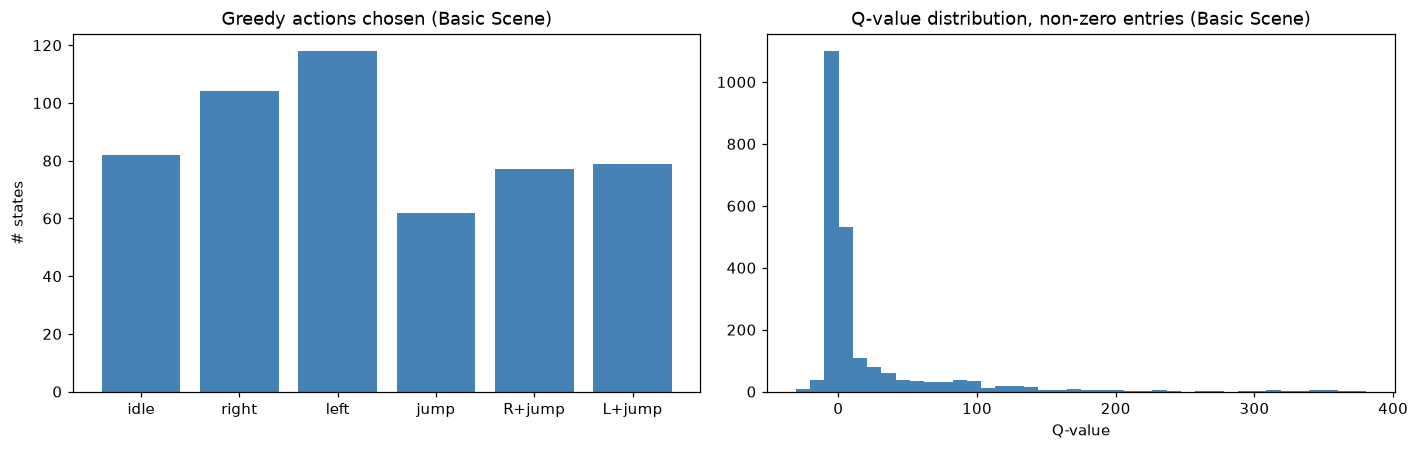

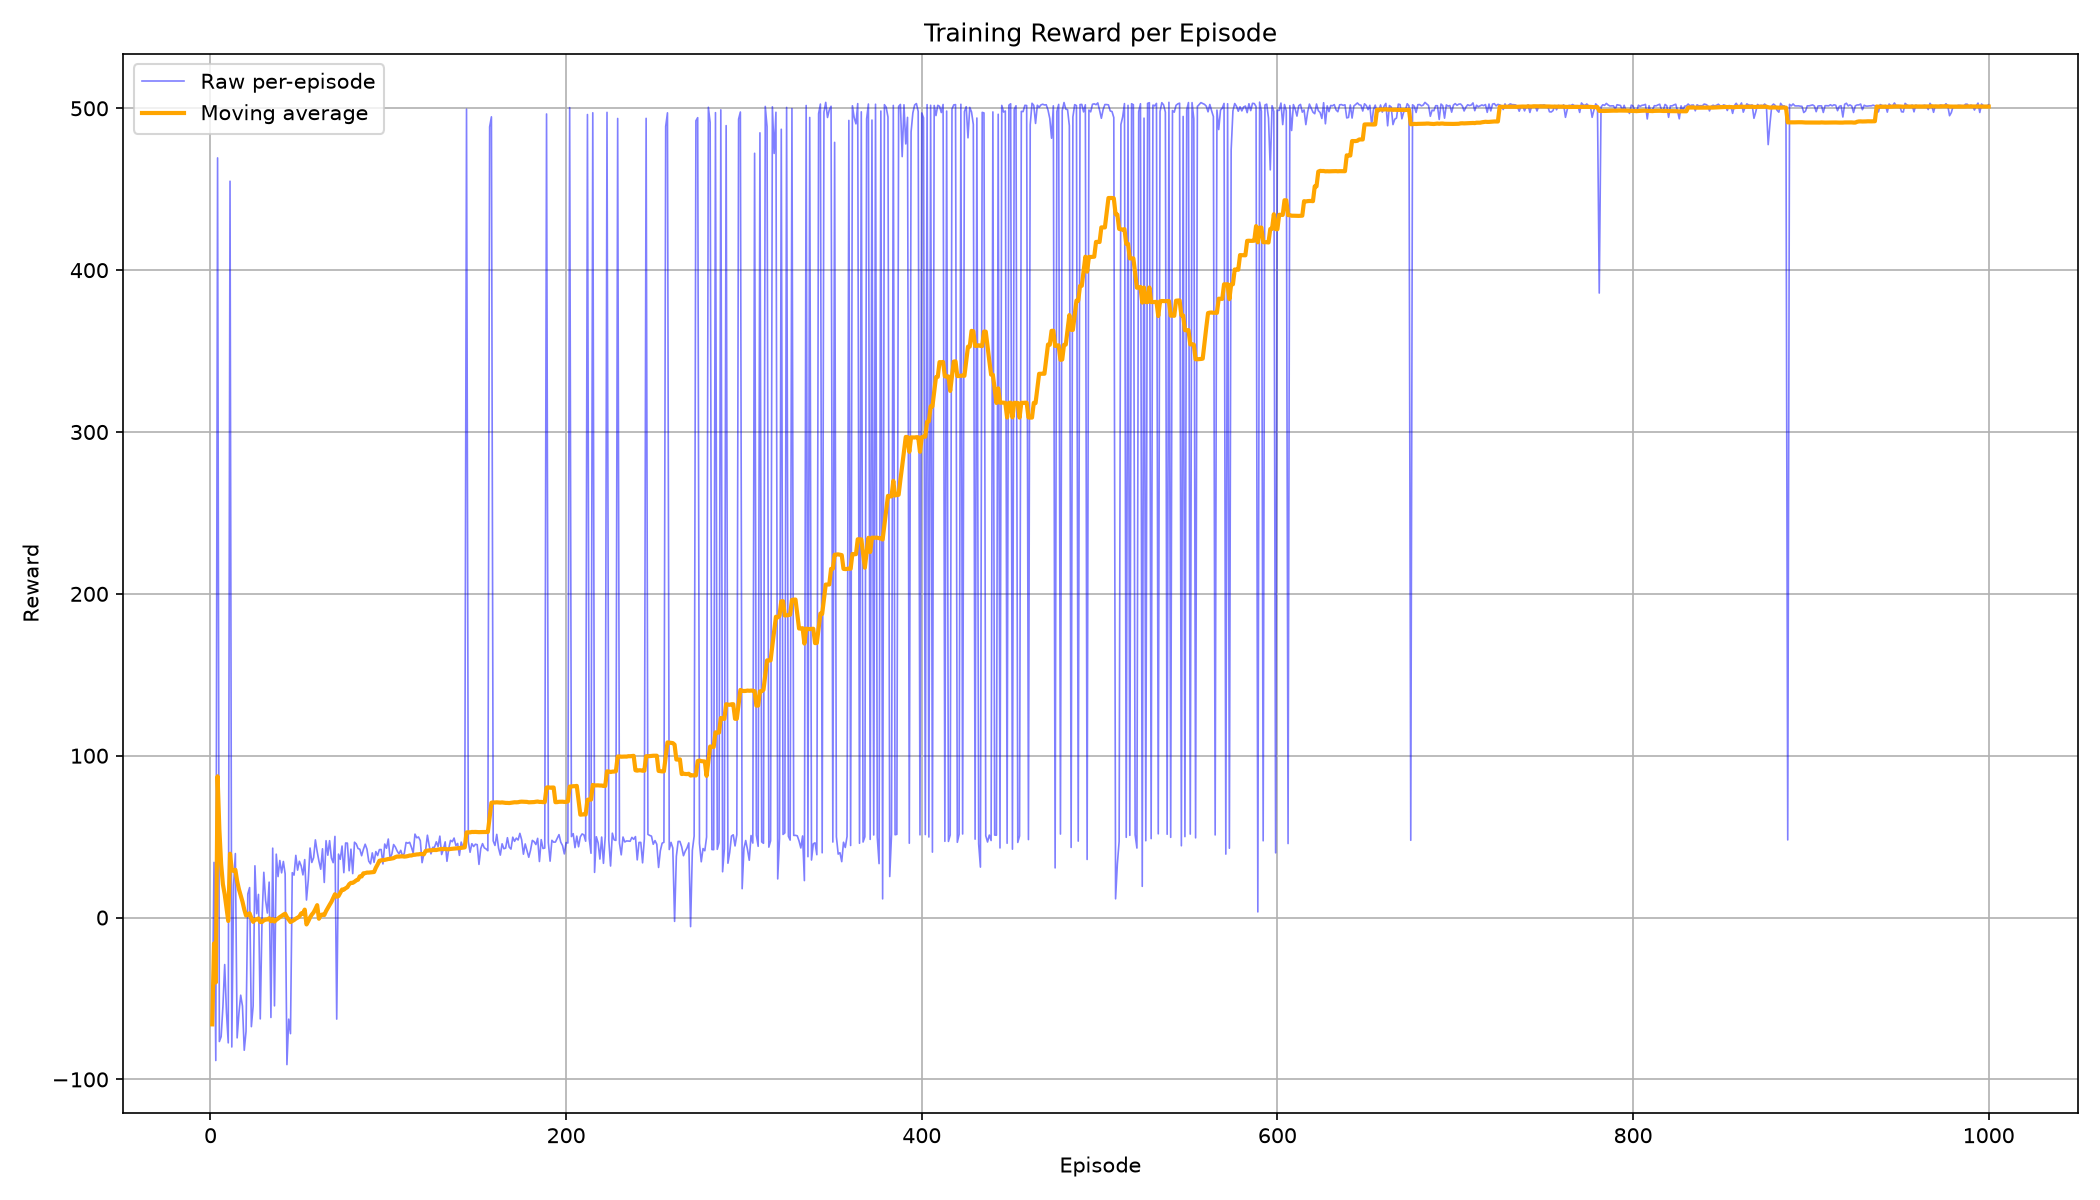

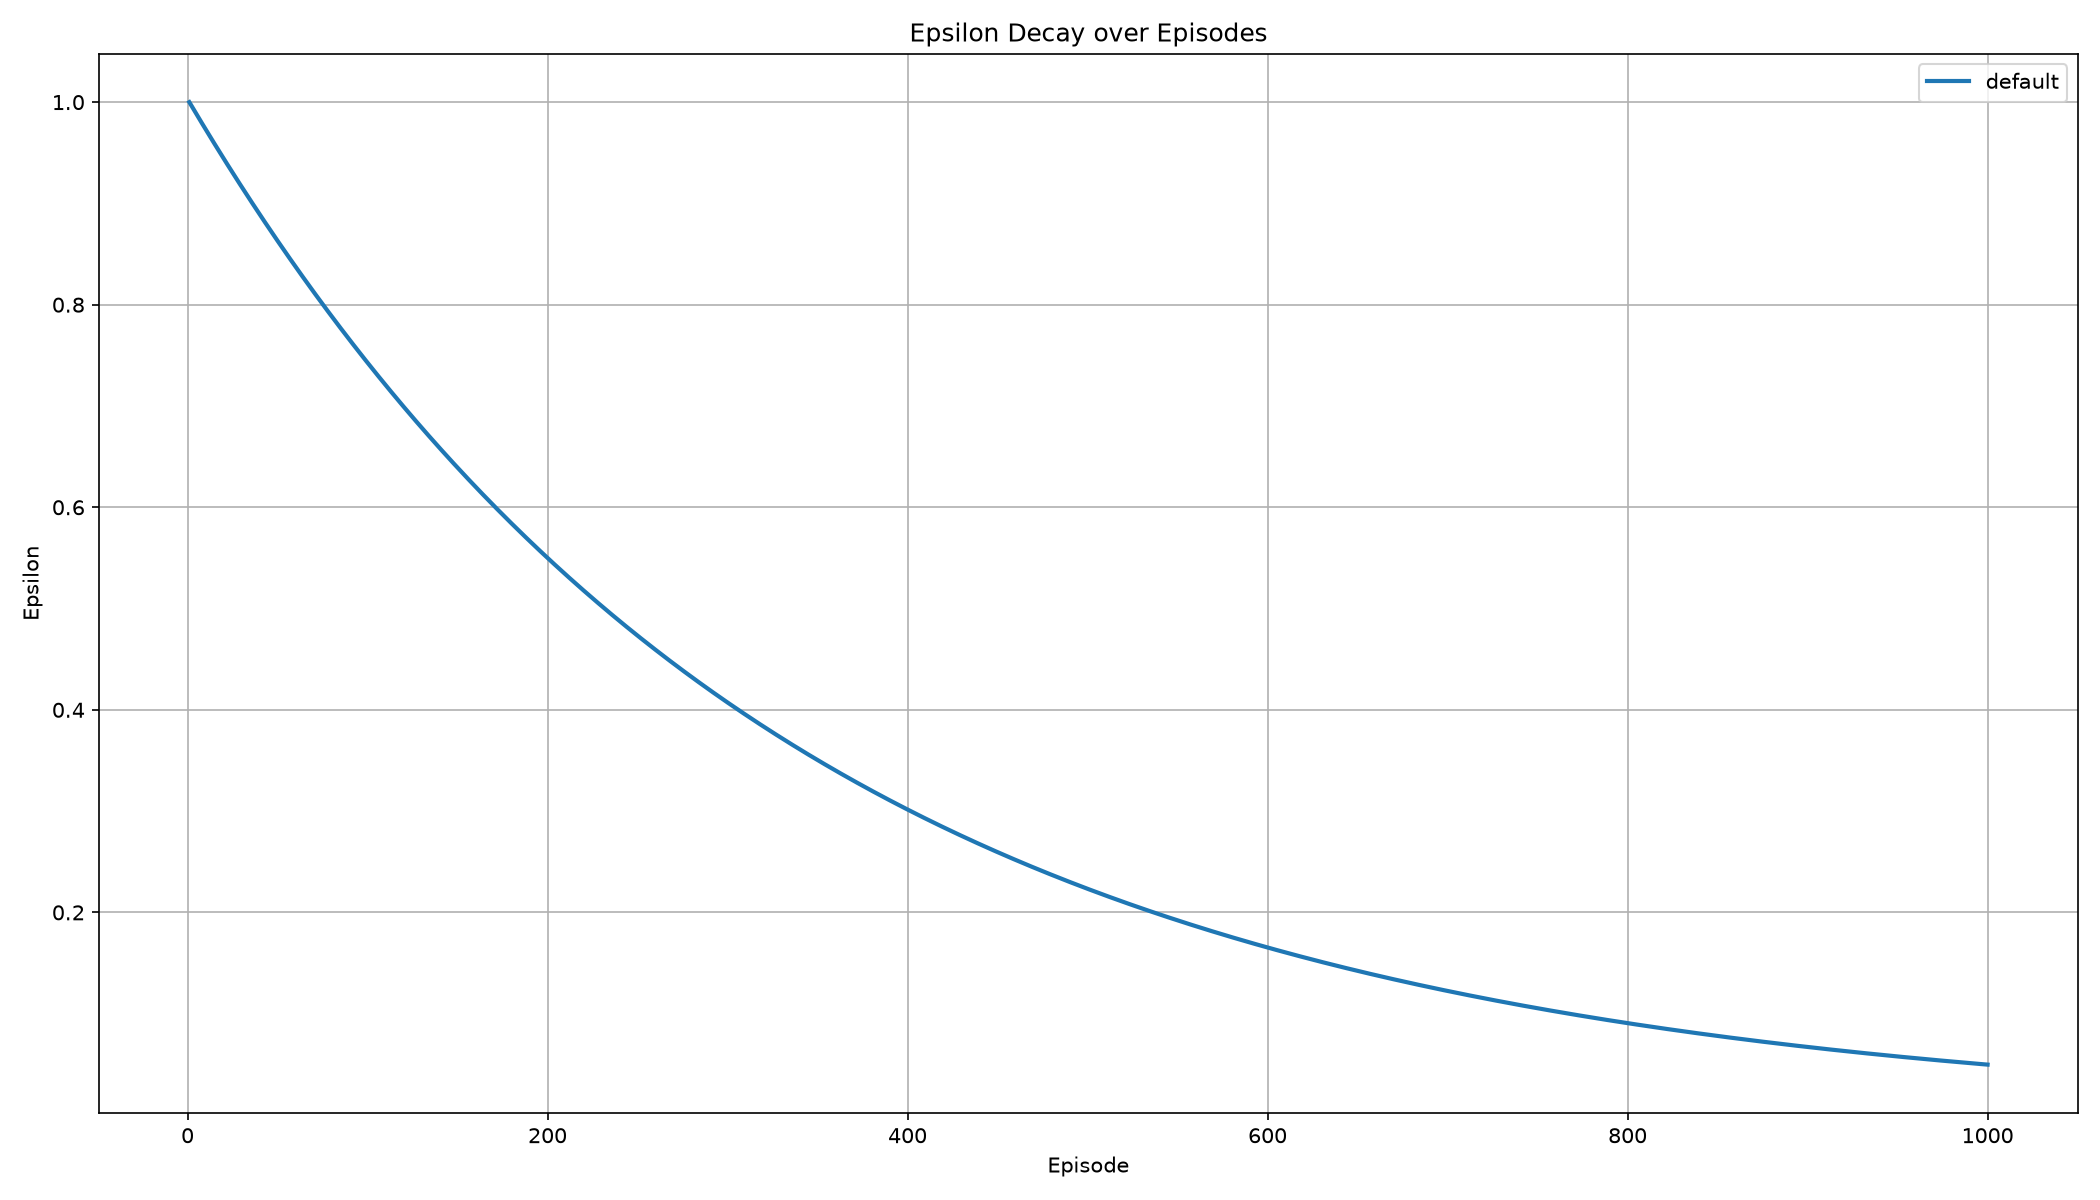

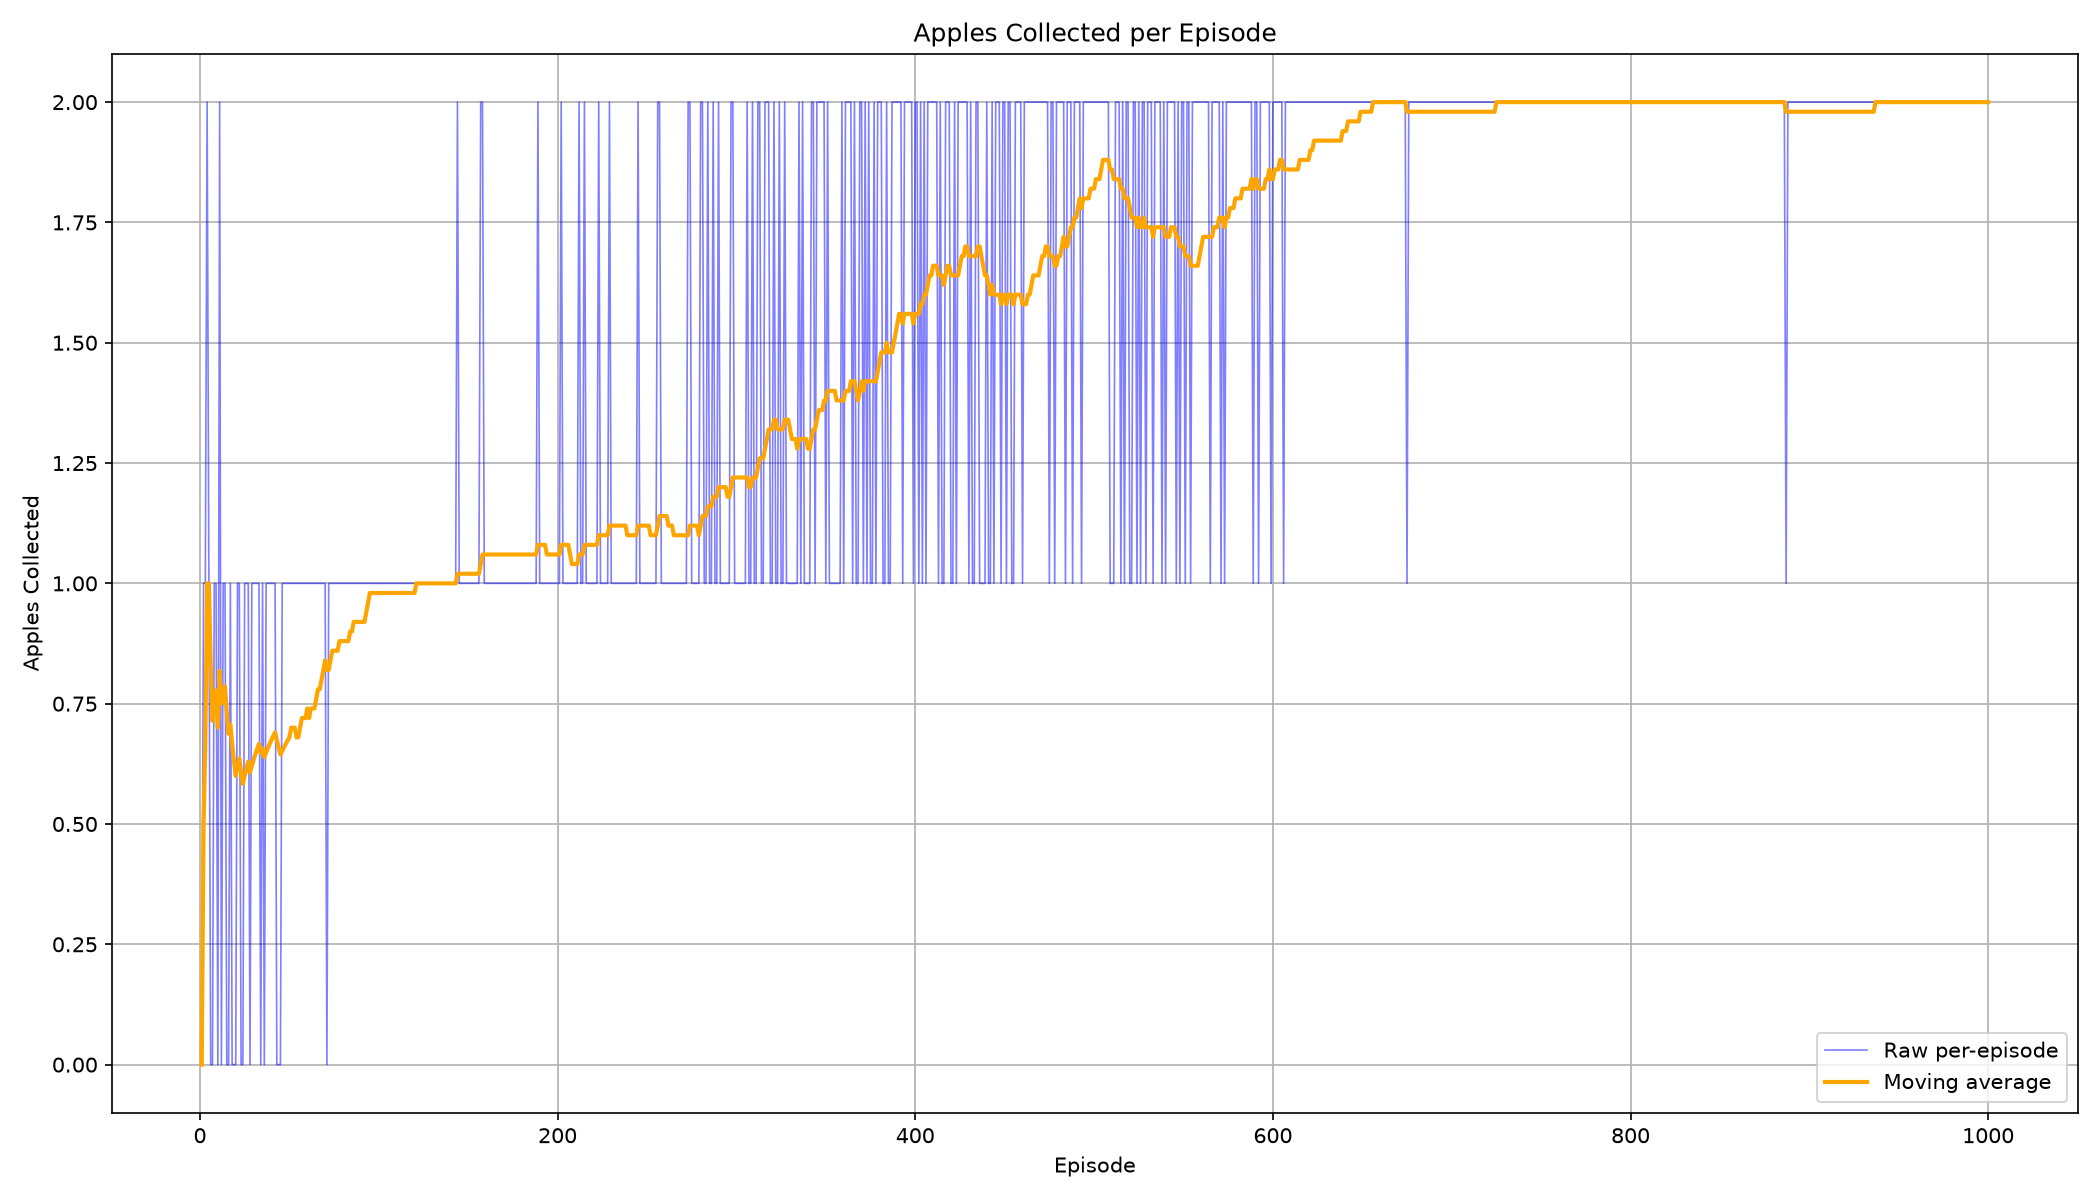

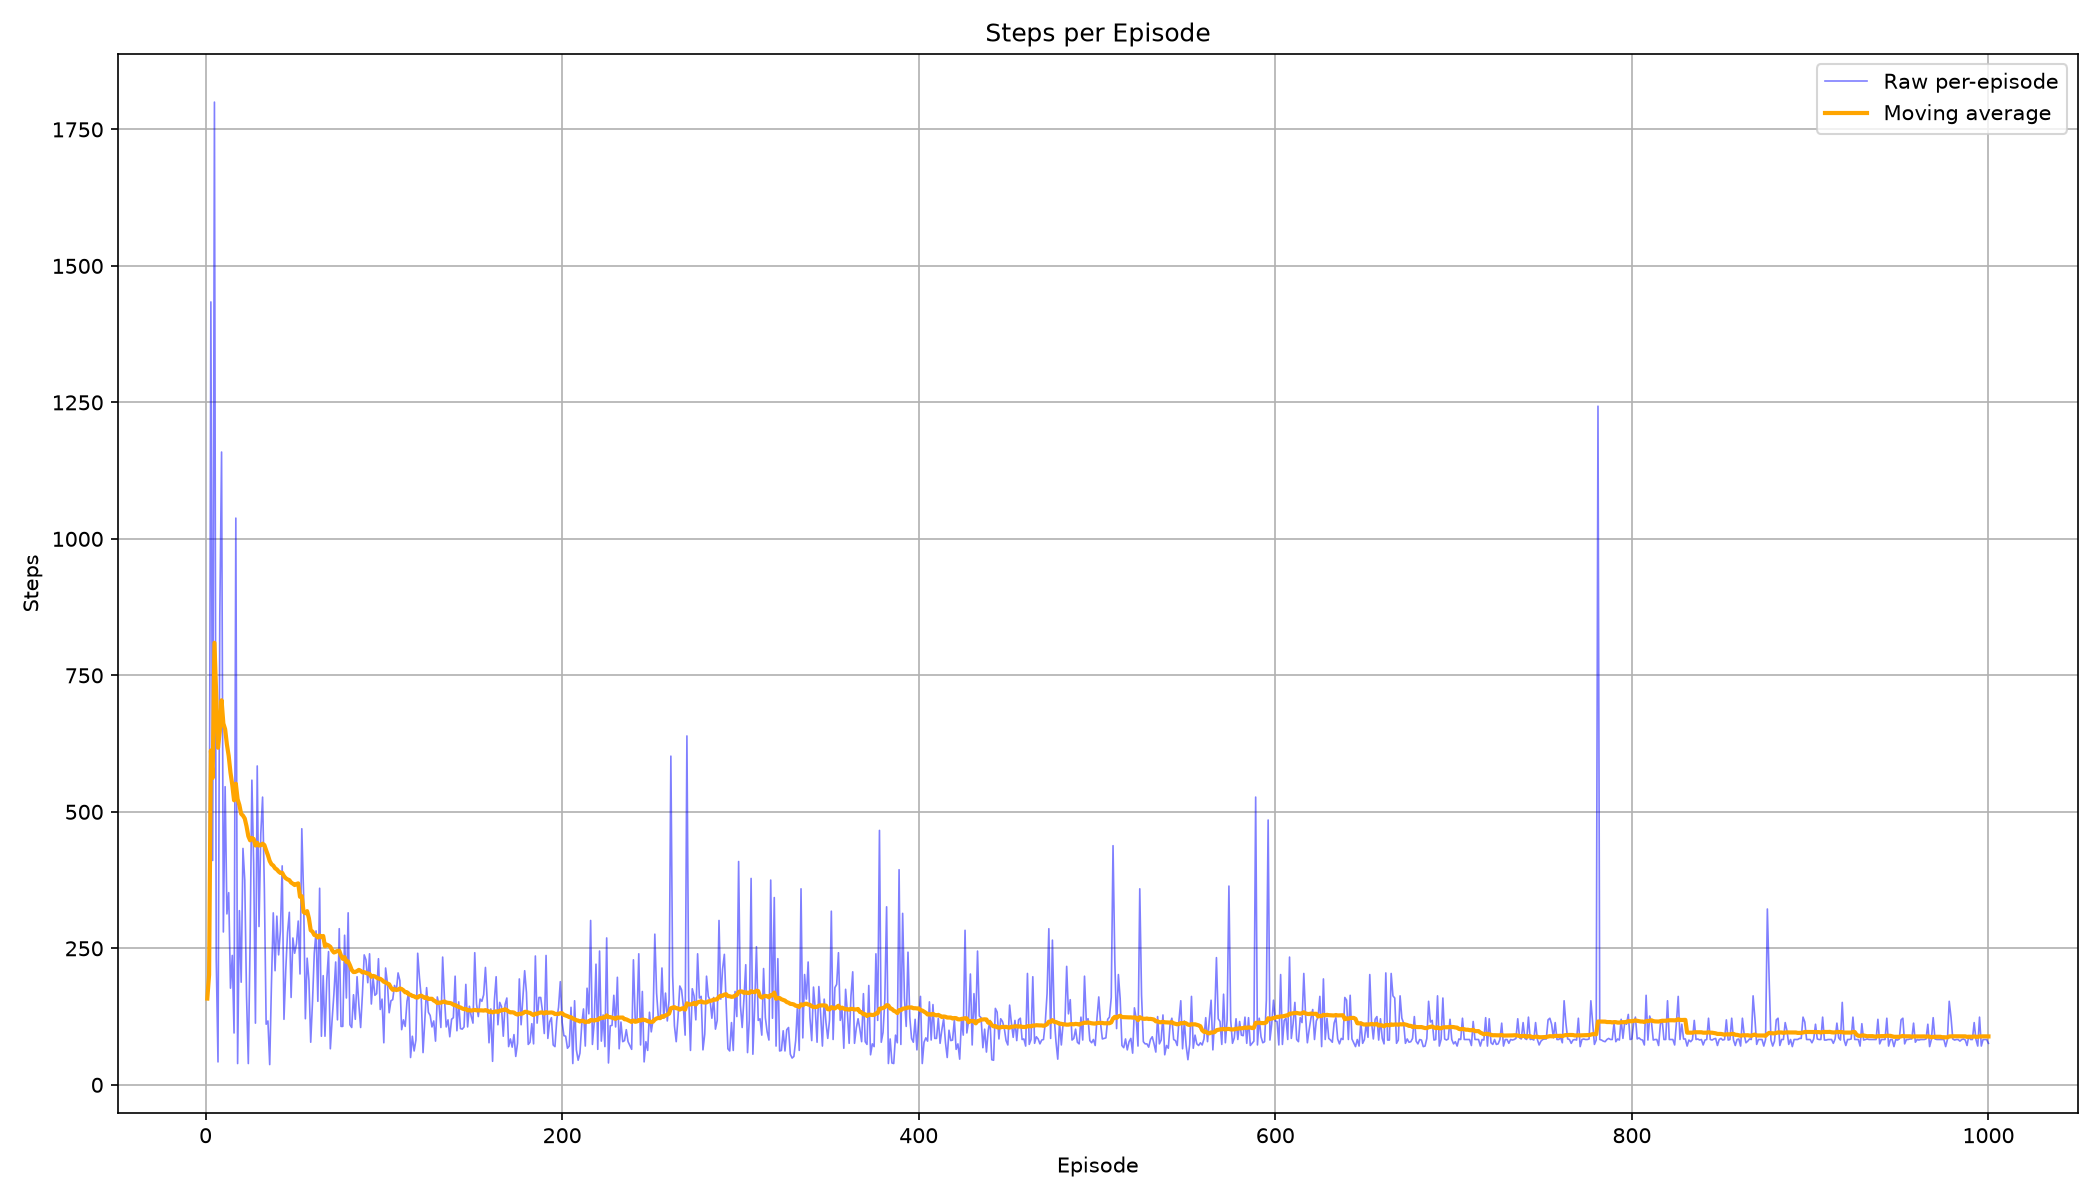

In [10]:
# Trained Q-table + curves from the completed run (loaded, not re-trained)
import pickle
from collections import Counter

with open(BASIC_RL / "qtable.pkl", "rb") as fh:
    q_table = pickle.load(fh)

def decode_state(s):
    px, py, og, adx, ady, adist, et, ac, ng = s
    return (f"px={px} (x~{(px + 0.5) / 8 * 100:.0f}%), py={py} (y~{(py + 0.5) / 5 * 100:.0f}%), "
            f"on_ground={og}, apple_dir=({adx - 1},{ady - 1}), "
            f"apple_dist={'near' if adist == 0 else 'far'}, enemy_timing={et}, "
            f"apples_collected={ac}, near_gap={ng}")

states = {s for (s, _) in q_table}
entries = len(q_table)
nonzero = [(s, a, v) for (s, a), v in q_table.items() if v != 0.0]
best_counts = Counter()
for s in states:
    qs = [q_table.get((s, a), 0.0) for a in range(6)]
    best_counts[qs.index(max(qs))] += 1

print("Q-table entries          :", entries)
print("Distinct states visited  :", len(states), "/ 63,360")
print("Non-zero entries         :", len(nonzero), f"({100 * len(nonzero) / max(entries, 1):.1f}%)")
print("Max Q-value              : %.2f" % max(q_table.values()))
print("Min Q-value              : %.2f" % min(q_table.values()))
print("Mean Q (non-zero)        : %.2f" % (sum(v for _, _, v in nonzero) / max(len(nonzero), 1)))
action_names = ['idle', 'right', 'left', 'jump', 'R+jump', 'L+jump']
print("Greedy action usage (per-state argmax over known Q-values):")
for i in range(6):
    print(f"  {action_names[i]:<7}: {best_counts[i]:4d} states ({100 * best_counts[i] / max(len(states), 1):.1f}%)")
print()
print("Top-10 highest Q-value (state, action) pairs, with decoded state:")
for (s, a), v in sorted(q_table.items(), key=lambda kv: -kv[1])[:10]:
    print(f"  Q={v:9.2f}  action={a:<2}  state=({decode_state(s)})")
print()
top_state = max(states, key=lambda s: max(q_table.get((s, a), 0.0) for a in range(6)))
print("Example row of the Q-table - all 6 actions in the highest-value state:")
print(" ", decode_state(top_state))
for a in range(6):
    print(f"  action={action_names[a]:<7} Q={q_table.get((top_state, a), 0.0):8.2f}")

# Greedy action usage + Q-value distribution (new plots from the Q-table)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
axes[0].bar(action_names, [best_counts[i] for i in range(6)], color="steelblue")
axes[0].set_title(f"Greedy actions chosen (Basic Scene)")
axes[0].set_ylabel("# states")
axes[1].hist([v for _, _, v in nonzero], bins=40, color="steelblue")
axes[1].set_title(f"Q-value distribution, non-zero entries (Basic Scene)")
axes[1].set_xlabel("Q-value")
plt.tight_layout()
plt.show()

# Training curves saved by trainer.py::plot_results during the completed run
from IPython.display import Image as IPImage, display
for name in ["learning_curve", "epsilon_curve", "apples_curve", "steps_curve"]:
    display(IPImage(filename=str(BASIC_RL / f"{name}.png")))


## 10. Basic Scene — Deterministic Evaluation

**Requires Godot open with the Basic Scene (`main.tscn`) running.** Evaluates the trained Q-table with a greedy policy (ε = 0), never updating the table, over 50 episodes (`evaluate.py`) or 10 episodes (`tester.py`).

In [ ]:
# Run this cell with the Basic Scene open in Godot.
evaluate_agent(table_path=str(BASIC_RL / "qtable.pkl"), label="Basic Scene")

# Optional shorter run (tester.py, 10 episodes):
# test_agent(table_path=str(BASIC_RL / "qtable.pkl"), label="Basic Scene")


## 11. Advanced Scene — Training

The Advanced Scene (`level_root_advanced.tscn`) repositions the snail enemies to directly guard the apples, making the same task harder. The Q-learning agent is trained with the **identical** hyperparameters and state discretisation as the Basic Scene — only the scene loaded in Godot differs.

**Requires Godot open with `level_root_advanced.tscn` running and listening on port 9080.**

In [ ]:
# Run this cell with the Advanced Scene open in Godot to train from scratch.
env = GodotEnv()
if not env.connect():
    raise SystemExit("Godot not running - open the Advanced Scene and press F5 first.")

agent = QLearning(LEARNING_RATE, DISCOUNT_FACTOR)
try:
    agent.load(str(ADVANCED_RL / "qtable.pkl"))
    print("Resuming from existing Q-table:", len(agent.q_table), "entries")
except FileNotFoundError:
    print("No qtable.pkl yet - training from scratch.")

history = train_agent(env, agent, EXPERIMENTS["default"], label="advanced", debug=False)
agent.save(str(ADVANCED_RL / "qtable.pkl"))
plot_results([history], save_dir=str(ADVANCED_RL))
env.disconnect()


## 12. Advanced Scene — Training Results

Loaded directly from the completed run's saved files — `qtable.pkl` and the four training-curve PNGs in `as-4_advanced/reinforcement_learning/`. The agent visited **1053 / 63,360** distinct states (roughly twice the Basic Scene), consistent with the harder enemy placement. The curves below are the historical outputs of the run itself, embedded here unchanged.

Q-table entries          : 6318
Distinct states visited  : 1053 / 63,360
Non-zero entries         : 4499 (71.2%)
Max Q-value              : 387.58
Min Q-value              : -23.51
Mean Q (non-zero)        : 12.11
Greedy action usage (per-state argmax over known Q-values):
  idle   :  137 states (13.0%)
  right  :  257 states (24.4%)
  left   :  208 states (19.8%)
  jump   :  134 states (12.7%)
  R+jump :  129 states (12.3%)
  L+jump :  188 states (17.9%)

Top-10 highest Q-value (state, action) pairs, with decoded state:
  Q=   387.58  action=4   state=(px=0 (x~6%), py=2 (y~50%), on_ground=0, apple_dir=(1,0), apple_dist=near, enemy_timing=5, apples_collected=1, near_gap=0)
  Q=   387.04  action=4   state=(px=0 (x~6%), py=2 (y~50%), on_ground=0, apple_dir=(1,0), apple_dist=near, enemy_timing=6, apples_collected=1, near_gap=0)
  Q=   376.32  action=0   state=(px=0 (x~6%), py=2 (y~50%), on_ground=0, apple_dir=(1,1), apple_dist=near, enemy_timing=5, apples_collected=1, near_gap=0)
  Q=   3

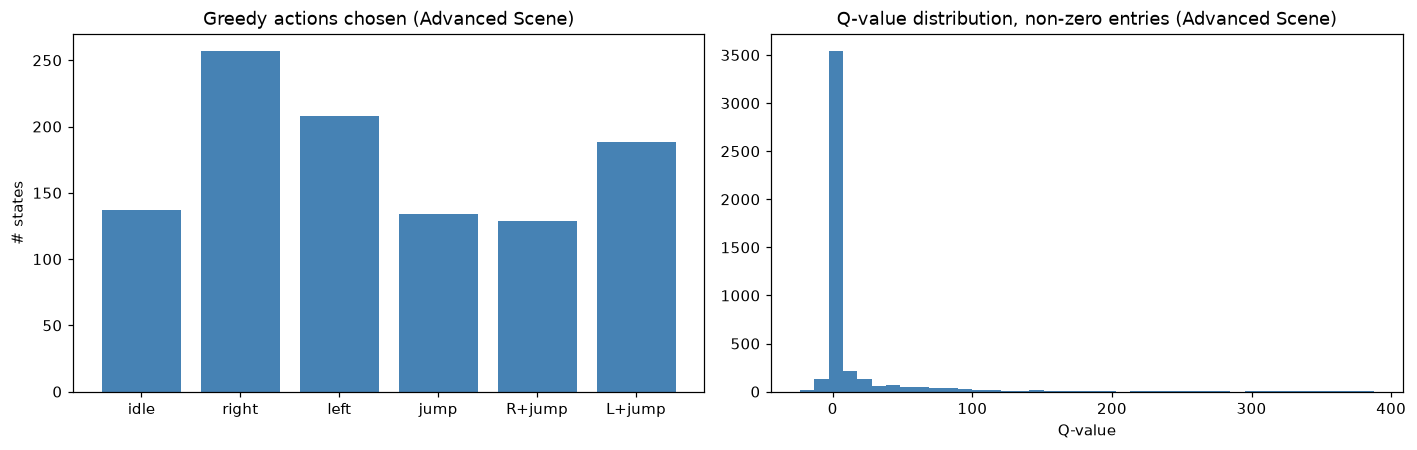

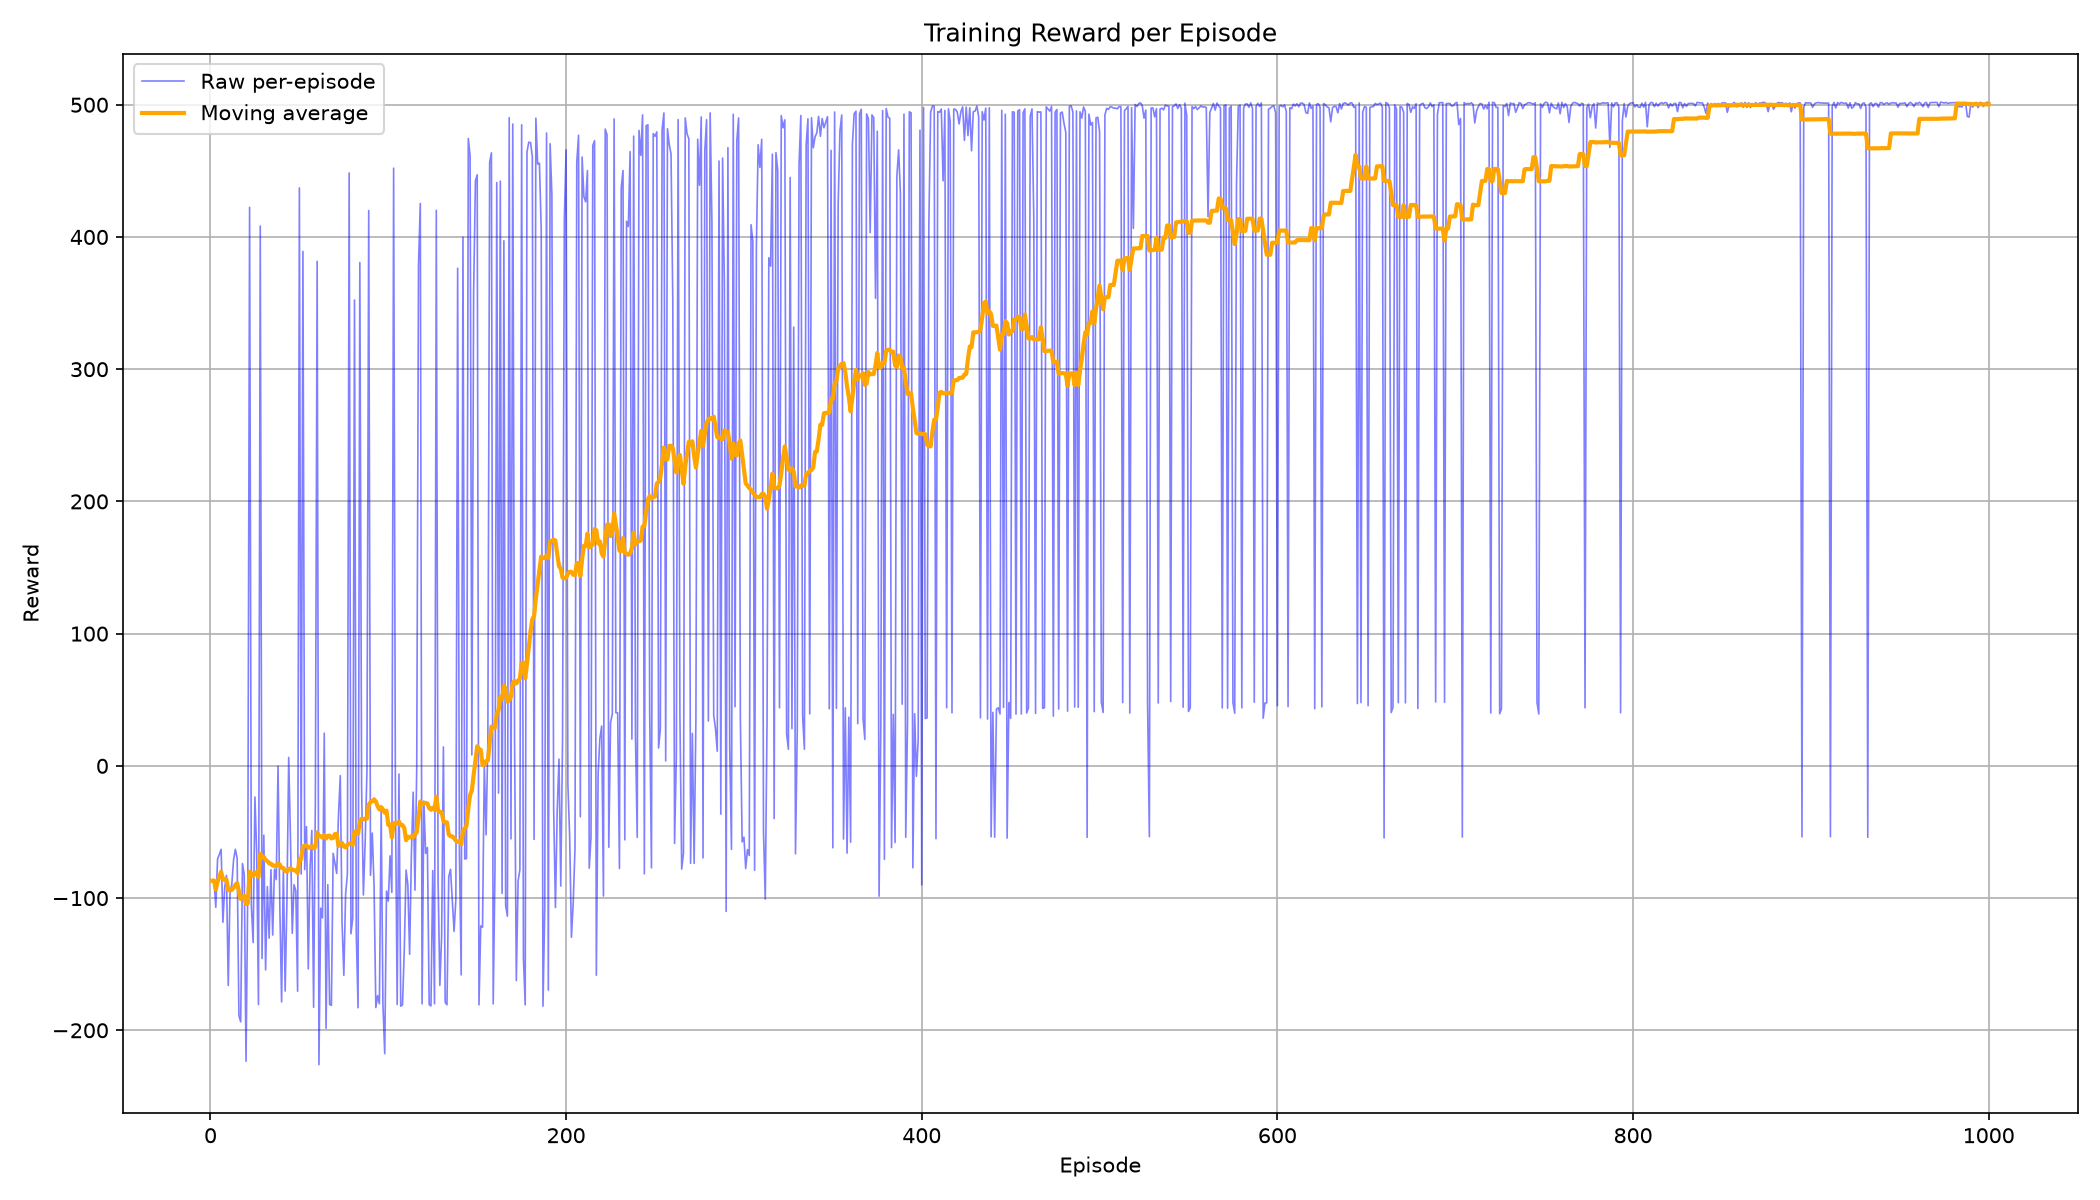

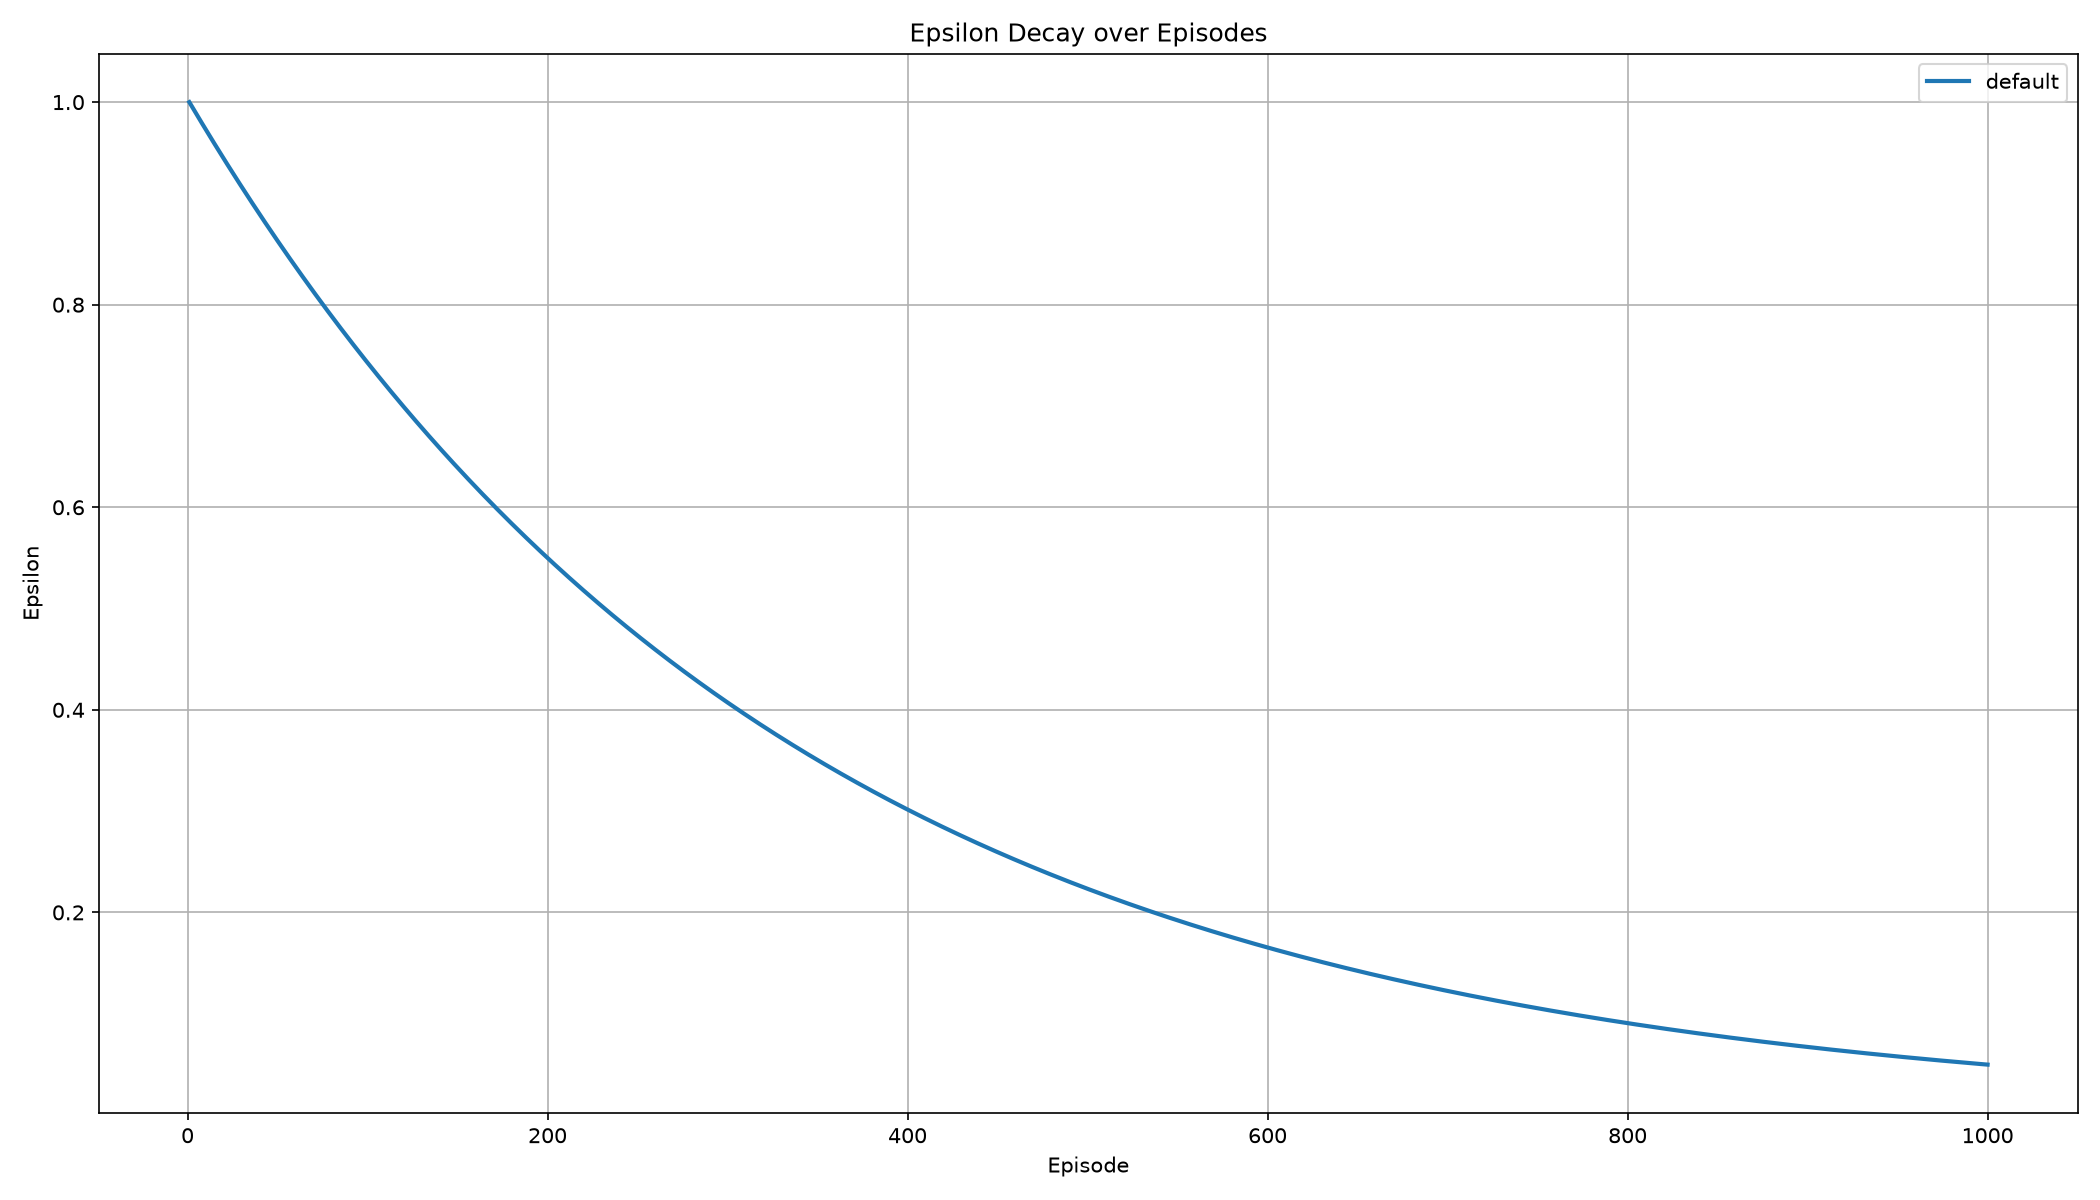

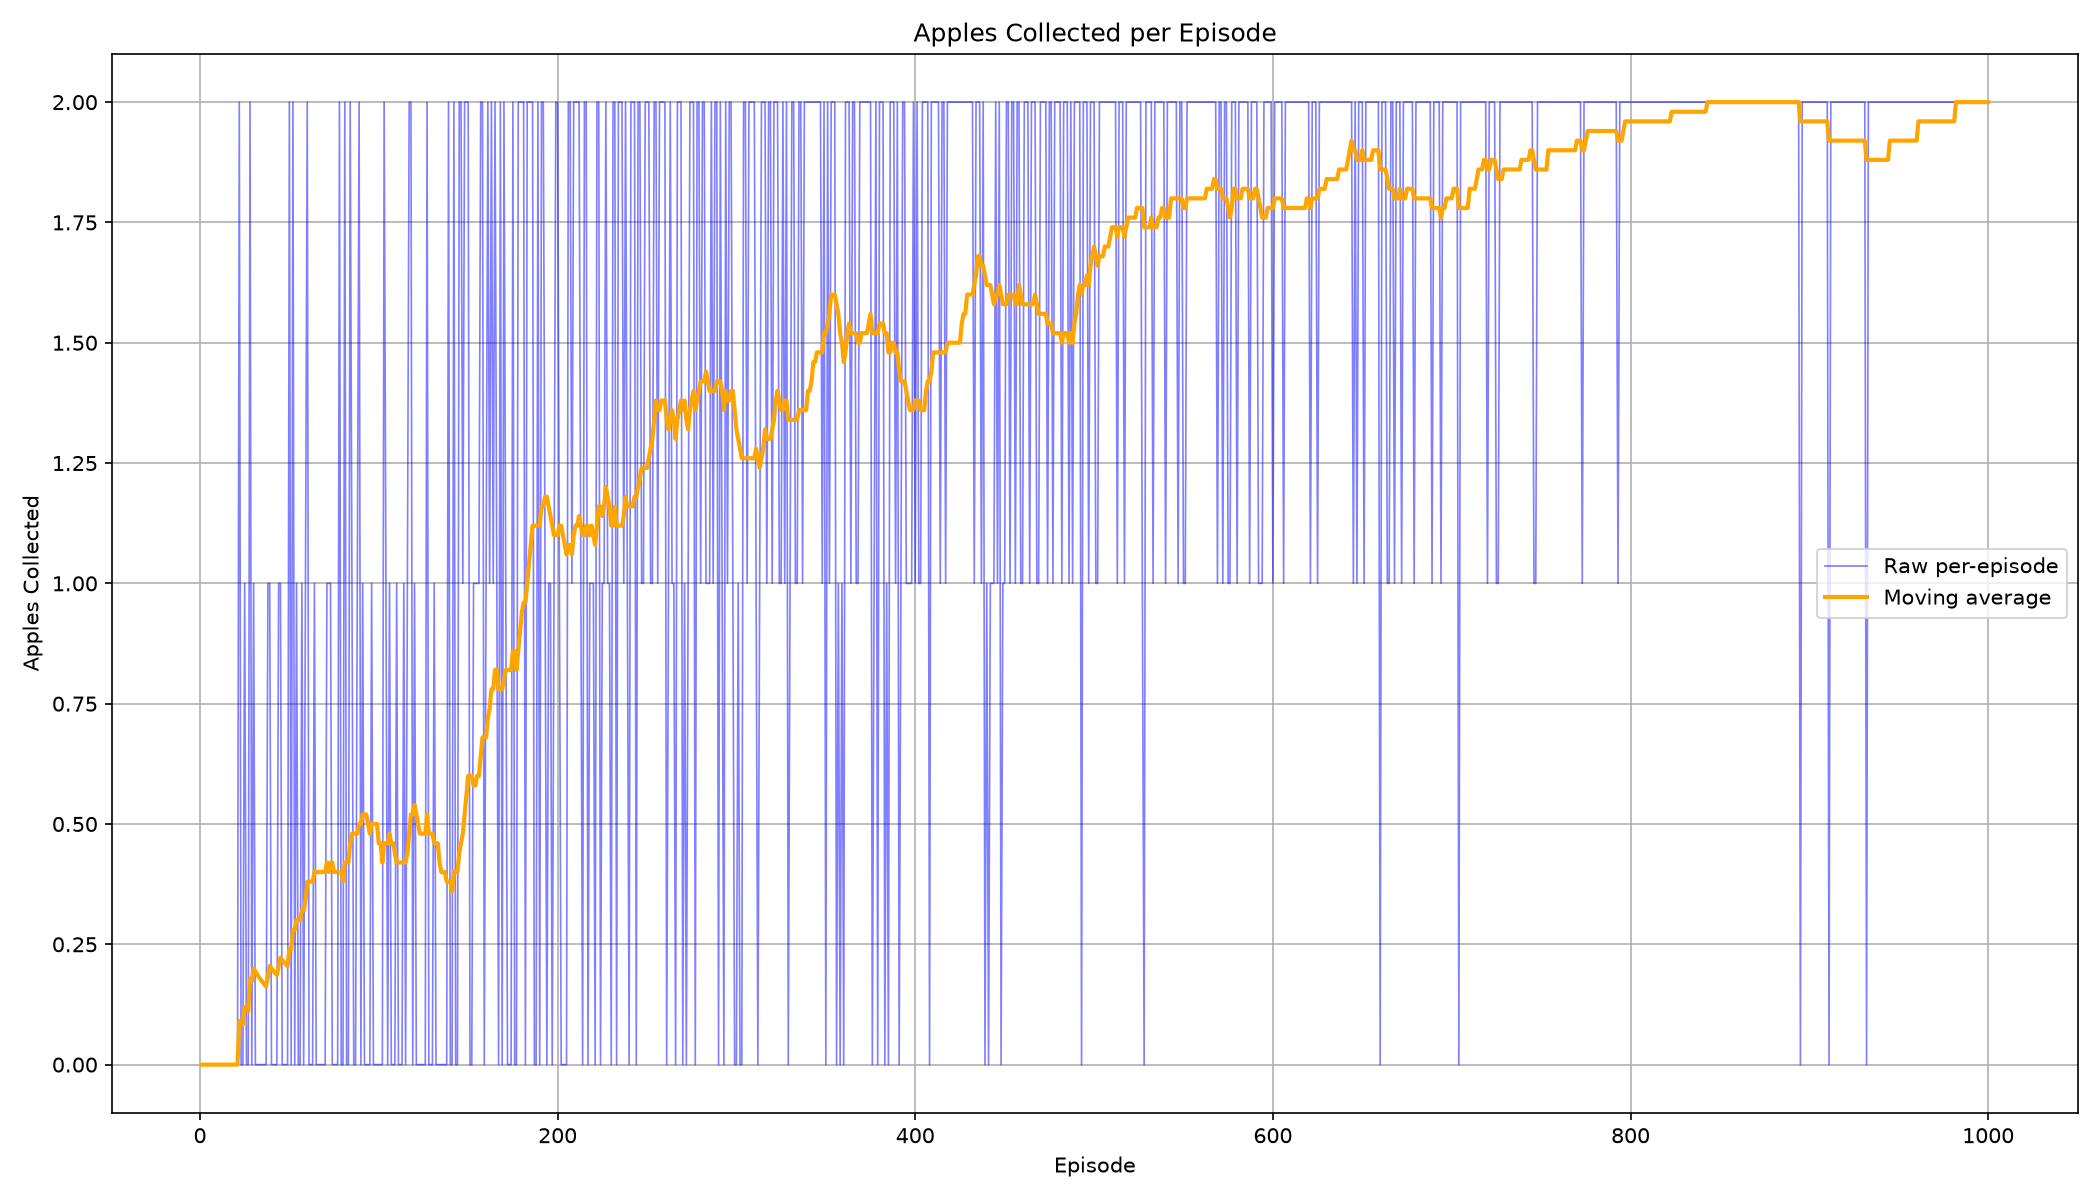

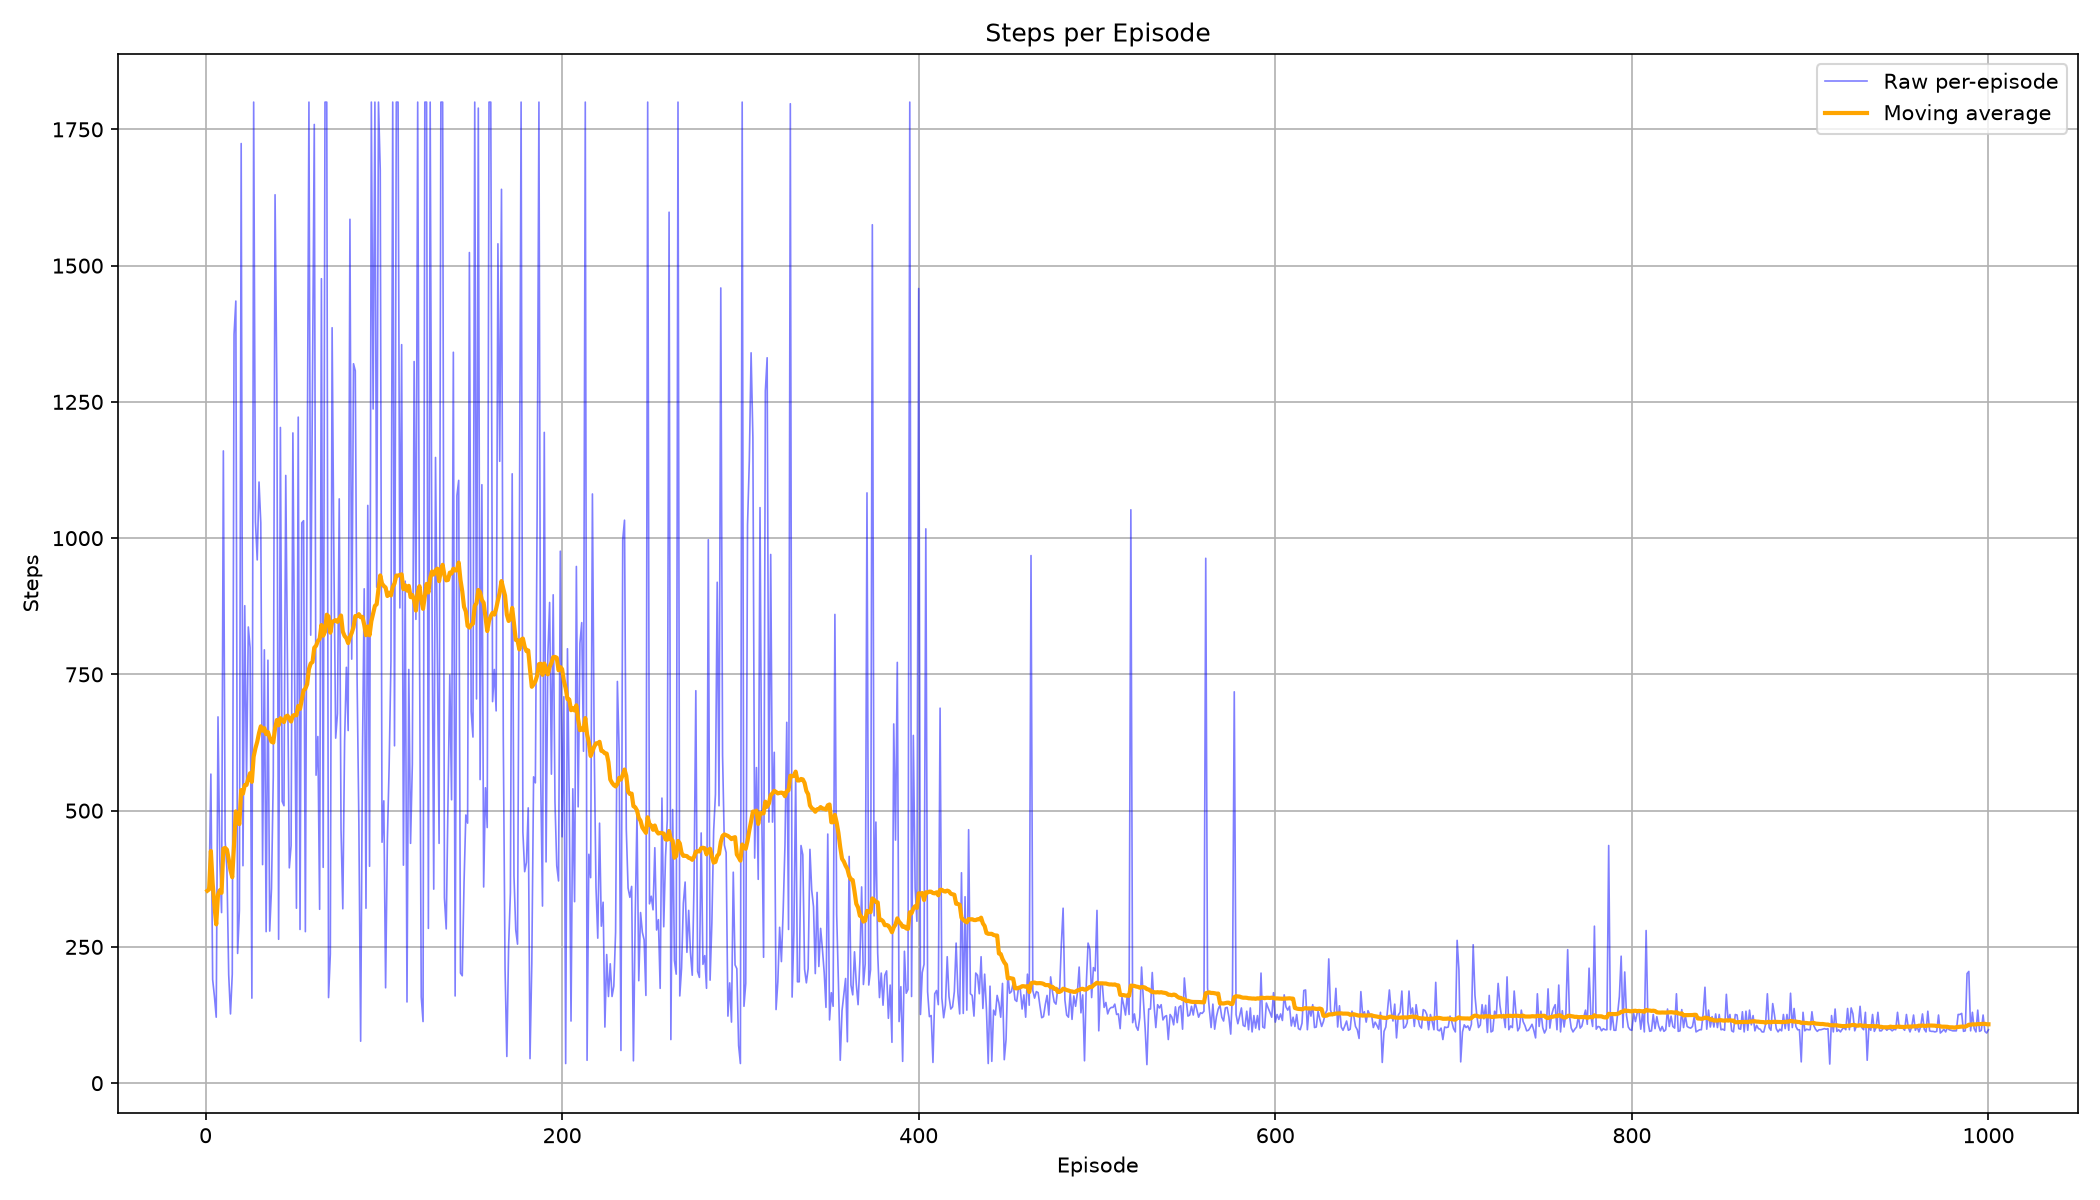

In [11]:
# Trained Q-table + curves from the completed run (loaded, not re-trained)
import pickle
from collections import Counter

with open(ADVANCED_RL / "qtable.pkl", "rb") as fh:
    q_table = pickle.load(fh)

def decode_state(s):
    px, py, og, adx, ady, adist, et, ac, ng = s
    return (f"px={px} (x~{(px + 0.5) / 8 * 100:.0f}%), py={py} (y~{(py + 0.5) / 5 * 100:.0f}%), "
            f"on_ground={og}, apple_dir=({adx - 1},{ady - 1}), "
            f"apple_dist={'near' if adist == 0 else 'far'}, enemy_timing={et}, "
            f"apples_collected={ac}, near_gap={ng}")

states = {s for (s, _) in q_table}
entries = len(q_table)
nonzero = [(s, a, v) for (s, a), v in q_table.items() if v != 0.0]
best_counts = Counter()
for s in states:
    qs = [q_table.get((s, a), 0.0) for a in range(6)]
    best_counts[qs.index(max(qs))] += 1

print("Q-table entries          :", entries)
print("Distinct states visited  :", len(states), "/ 63,360")
print("Non-zero entries         :", len(nonzero), f"({100 * len(nonzero) / max(entries, 1):.1f}%)")
print("Max Q-value              : %.2f" % max(q_table.values()))
print("Min Q-value              : %.2f" % min(q_table.values()))
print("Mean Q (non-zero)        : %.2f" % (sum(v for _, _, v in nonzero) / max(len(nonzero), 1)))
action_names = ['idle', 'right', 'left', 'jump', 'R+jump', 'L+jump']
print("Greedy action usage (per-state argmax over known Q-values):")
for i in range(6):
    print(f"  {action_names[i]:<7}: {best_counts[i]:4d} states ({100 * best_counts[i] / max(len(states), 1):.1f}%)")
print()
print("Top-10 highest Q-value (state, action) pairs, with decoded state:")
for (s, a), v in sorted(q_table.items(), key=lambda kv: -kv[1])[:10]:
    print(f"  Q={v:9.2f}  action={a:<2}  state=({decode_state(s)})")
print()
top_state = max(states, key=lambda s: max(q_table.get((s, a), 0.0) for a in range(6)))
print("Example row of the Q-table - all 6 actions in the highest-value state:")
print(" ", decode_state(top_state))
for a in range(6):
    print(f"  action={action_names[a]:<7} Q={q_table.get((top_state, a), 0.0):8.2f}")

# Greedy action usage + Q-value distribution (new plots from the Q-table)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
axes[0].bar(action_names, [best_counts[i] for i in range(6)], color="steelblue")
axes[0].set_title(f"Greedy actions chosen (Advanced Scene)")
axes[0].set_ylabel("# states")
axes[1].hist([v for _, _, v in nonzero], bins=40, color="steelblue")
axes[1].set_title(f"Q-value distribution, non-zero entries (Advanced Scene)")
axes[1].set_xlabel("Q-value")
plt.tight_layout()
plt.show()

# Training curves saved by trainer.py::plot_results during the completed run
from IPython.display import Image as IPImage, display
for name in ["learning_curve", "epsilon_curve", "apples_curve", "steps_curve"]:
    display(IPImage(filename=str(ADVANCED_RL / f"{name}.png")))


## 13. Advanced Scene — Deterministic Evaluation

**Requires Godot open with `level_root_advanced.tscn` running.** Evaluates the trained Q-table with a greedy policy (ε = 0) over 50 episodes (`evaluate.py`) or 10 episodes (`tester.py`) — identical procedure to the Basic Scene.

In [ ]:
# Run this cell with the Advanced Scene open in Godot.
evaluate_agent(table_path=str(ADVANCED_RL / "qtable.pkl"), label="Advanced Scene")

# Optional shorter run (tester.py, 10 episodes):
# test_agent(table_path=str(ADVANCED_RL / "qtable.pkl"), label="Advanced Scene")


## 14. Summary

| Metric | Basic Scene | Advanced Scene |
|---|---|---|
| Training experiment | default (1,000 episodes) | default (1,000 episodes) |
| Hyperparameters | lr 0.1, γ 0.98, ε 1.0→0.02 (×0.997) | identical |
| Q-table entries | 3132 | 6318 |
| Distinct states visited | 522 / 63,360 | 1053 / 63,360 |
| Non-zero entries | 2271 (72.5%) | 4499 (71.2%) |
| Max / min Q-value | 380.54 / -30.67 | 387.58 / -23.51 |
| Mean Q-value (non-zero) | 20.59 | 12.11 |

Both scenes are solved with the same algorithm and hyperparameters; only the enemy placement in the Godot scene differs. The Advanced Scene's larger visited-state count and lower mean Q-value reflect the harder task, while both Q-tables reach high terminal rewards (max Q ≈ 380.54 vs 387.58).

Full discussion of these results is provided in the accompanying report.